In [1]:
import numpy as np
import scipy.stats as scs
from matplotlib import pyplot as plt
from tqdm import tqdm
from scipy.spatial.distance import pdist
from sklearn.gaussian_process.kernels import Matern
import torch
import torch.nn as nn
import gpytorch

In [2]:
def Spatial_Energy_Score_sublocs(theta,beta,sub_locs,days_nb,sim_nb,observations_x,censor_levels_di,dist_matrix,topo_matrix=None):
    '''
    theta: vector of 3 [Matern_param, coef_distmat, coef_topomat]. The coefs are applied to the matricies to form the ditance matrix used as input in the Matern kernel to form the covariance.
    sub_locs: a set of subsets of location indexes with the same number of locs in each.
    days_nb: how many days to include on the subsample.
    sim_nb: number of simulation draws to compare with original data in the score.
    observations_x: x, observed rainfall transformed to a Gaussian normal scale. This is the data that we try to emulate.
    censor_levels_di: d, probability of no rain (1-p) transformed to a normal scale. These are used to censor simulations (x') when comparingt to x.
    '''
    # Subsample locations. Choose a random subset the list of subsets - sub_locs.
    locs = sub_locs[np.random.choice(range(len(sub_locs)))] 
    locs_nb = len(locs)
    # Subsample days.
    days = np.random.choice(range(len(observations_x)),size=days_nb,replace=False)

    # Select relevant subsamples of data.
    x = observations_x[days,:][:,locs]
    d = censor_levels_di[days,:][:,locs]
    
    # Create covariance matrix.
    if np.sum(topo_matrix==None):
        cov_mat = np.nan_to_num(Matern(length_scale=theta,nu=3.5).__call__(dist_matrix[locs,:][:,locs]))
    else:
        cov_mat = np.nan_to_num(Matern(length_scale=theta[0],nu=3.5).__call__(theta[1]*dist_mat[locs,:][:,locs]+((1-theta[1])/70)*topo_dist[locs,:][:,locs]))

    # Draw samples from the multivariate nromal with appropriate covariance.
    simulations = scs.multivariate_normal(mean=np.zeros(locs_nb),cov=cov_mat,allow_singular=True).rvs(size=sim_nb)
    
    # Censor simulated values and format them into [[sim0-day0,sim0-day1,...,sim0-dayn] ,..., [sim_m-day0,sim_m-day1,...,sim_m-dayn]]. Gives sim_nb*days_nb=m*n vectors of len=locs_nb. 
    censored_sims = np.maximum(np.repeat(simulations,days_nb,axis=0),np.tile(d,(sim_nb,1)))

    # ||x' - x' ||_2 component of energy score
    sims_by_day = [censored_sims[0+k::days_nb] for k in range(days_nb)] # regroup to get [[sim(1,day1), sim(2,day1),...,sim(m,day1)],...,[sim(1,dayn), sim(2,dayn),...,sim(m,dayn)]].
    
    sim_L2_diff = 0
    
    for sim_day_i in sims_by_day: # don't know how to make it more efficient... maybe can parallelize to compute complete score
        
        # ||x' - x' ||_2 component of energy score
            # OLD: einsum from Lorenzos code on each sim_day_i was 9x slower then doing pdist on each sim_day_i. Both give the same answer
        '''
        # matrix of all combinations over i of [vector_i-vector_1, ... , vector_i-vector_n]
        temp_diff_combinations_matrix = sim_day_i.reshape(1,sim_nb,locs_nb)-sim_day_i.reshape(sim_nb,1,locs_nb) 
        # einsum creates a matrix of sum of squares, then take sqrt to get L2.
        sim_L2_diff+=0.5*np.sum(np.sqrt(np.einsum('ijk, ijk -> ij',temp_diff_combinations_matrix,temp_diff_combinations_matrix))) 
        '''
            # New: pdist takes the offdiagonal of an L2 distance matrix, only counting once each combination of Y,Y'.
        sim_L2_diff+= 2 * np.sum(np.power(pdist(sim_day_i),beta))

    # Add both parts of Energy.
    Energy = 2 * np.mean(np.power(np.linalg.norm(censored_sims - np.tile(x,(sim_nb,1)),axis=1),beta)) - sim_L2_diff/(days_nb*sim_nb*(sim_nb-1))
    
    
    #path_.append([theta,Energy])
    print([theta,Energy])

    return Energy

path_avg = []

def Spatial_Energy_Score_sublocs_averaged(theta,beta,sub_locs,days_nb,sim_nb,observations_x,censor_levels_di,dist_matrix,topo_matrix,avg_nb):
    avg_SR = 0

    for s in range(avg_nb):
        avg_SR+= Spatial_Energy_Score_sublocs(theta,beta,sub_locs,days_nb,sim_nb,observations_x,censor_levels_di,dist_matrix,topo_matrix)

    path_avg.append(avg_SR/avg_nb)
    
    return avg_SR/avg_nb

# Minimal examples

## 2D Gaussian with $\rho$ directly

In [5]:
def Energy_Score(energy_beta, observations_y, simulations_Y):
    m = len(simulations_Y)
    diff_Y_y = torch.pow(
        torch.norm(
            (observations_y.unsqueeze(1) -
             simulations_Y.unsqueeze(0)).float(),
            dim=2, keepdim=True).reshape(-1, 1),
        energy_beta)
    diff_Y_Y = 2 * torch.pow(
        nn.functional.pdist(simulations_Y),
        energy_beta)
    Energy = 2 * torch.mean(diff_Y_y) - torch.sum(diff_Y_Y) / (m * (m - 1))
    return Energy

### 2D Fully observed Gaussian copula inference of $\rho$ directly

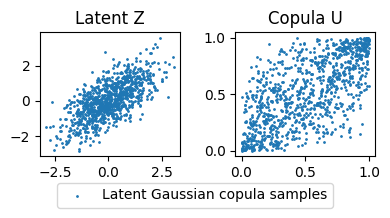

In [6]:
# generate Gaussian data for copula

latent_z = scs.multivariate_normal.rvs(mean=[0, 0], cov=[[1, 0.7], [0.7, 1]], size=1000)
copula_u = scs.norm.cdf(latent_z)
fig, axes = plt.subplots(1, 2, figsize=(4, 2))

axes[0].scatter(latent_z[:, 0], latent_z[:, 1], s=1, label='Latent Gaussian copula samples')
axes[0].set_title('Latent Z')

axes[1].scatter(copula_u[:, 0], copula_u[:, 1], s=1)
axes[1].set_title('Copula U')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=2)
plt.tight_layout()
plt.show()

In [7]:
# On the Gaussian Scale
def sample_Gauss_2d(n, cov):
    latent_z = scs.multivariate_normal.rvs(mean=np.zeros(cov.shape[0]), cov=cov, size=n)
    return latent_z

def sample_Gauss_2d_fixed_noise(n, noise, chol_cov):
    latent_z = noise @ chol_cov.T
    return latent_z
fixed_noise = scs.norm.rvs(size=(1000, 2))

e_scores_per_rho = []
beta = 0.5
for i in tqdm(range(100)):
    rho = np.round((i+1)/101,2)
    chol_cov = np.linalg.cholesky([[1, rho], [rho, 1]])
    gauss2d_fixed_samples = sample_Gauss_2d_fixed_noise(1000, fixed_noise, chol_cov)
    gauss2d_samples = sample_Gauss_2d(1000, cov=np.array([[1, rho], [rho, 1]]))
    e_scores_per_rho.append([Energy_Score(beta, torch.tensor(latent_z), torch.tensor(gauss2d_samples)),Energy_Score(beta, torch.tensor(latent_z), torch.tensor(gauss2d_fixed_samples)),rho])

# On the Copula Scale
def sample_Gauss_2d_copula(n, cov):
    latent_z = scs.multivariate_normal.rvs(mean=np.zeros(cov.shape[0]), cov=cov, size=n)
    return scs.norm.cdf(np.clip(latent_z, -7, 7))

def sample_Gauss_2d_fixed_noise_copula(n, noise, chol_cov):
    latent_z = noise @ chol_cov.T
    return scs.norm.cdf(np.clip(latent_z, -7, 7))
fixed_noise = scs.norm.rvs(size=(1000, 2))

e_scores_per_rho_cop = []
beta = 0.5
for i in tqdm(range(100)):
    rho = np.round((i+1)/101,2)
    chol_cov = np.linalg.cholesky([[1, rho], [rho, 1]])
    cop2d_fixed_samples = sample_Gauss_2d_fixed_noise_copula(1000, fixed_noise, chol_cov)
    cop2d_samples = sample_Gauss_2d_copula(1000, cov=np.array([[1, rho], [rho, 1]]))
    e_scores_per_rho_cop.append([Energy_Score(beta, torch.tensor(copula_u), torch.tensor(cop2d_samples)),Energy_Score(beta, torch.tensor(copula_u), torch.tensor(cop2d_fixed_samples)),rho])


100%|██████████| 100/100 [00:03<00:00, 32.47it/s]


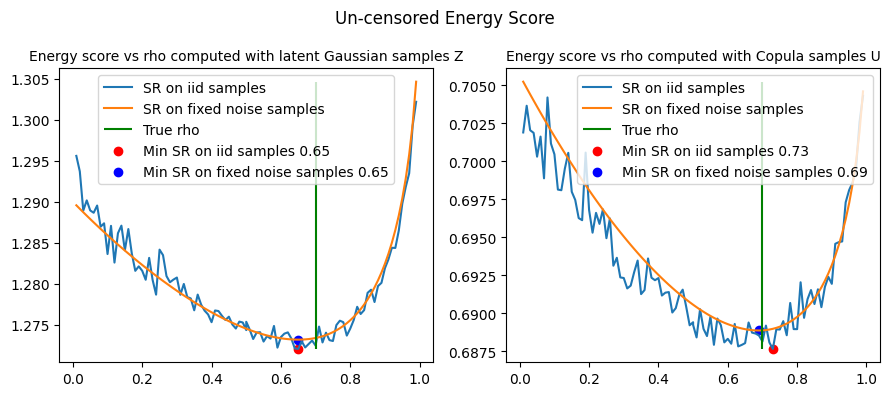

In [8]:
e_scores_per_rho = np.array(e_scores_per_rho)
e_scores_per_rho_cop = np.array(e_scores_per_rho_cop)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Plot for latent Gaussian samples Z
axes[0].set_title('Energy score vs rho computed with latent Gaussian samples Z',fontsize=10)
axes[0].plot(e_scores_per_rho[:, 2], e_scores_per_rho[:, 0], label='SR on iid samples')
axes[0].plot(e_scores_per_rho[:, 2], e_scores_per_rho[:, 1], label='SR on fixed noise samples')
axes[0].vlines(0.7, e_scores_per_rho[:, 0:2].min(), e_scores_per_rho[:, 0:2].max(), color='green', label='True rho')
axes[0].scatter(e_scores_per_rho[np.argmin(e_scores_per_rho[:, 0]), 2], e_scores_per_rho[np.argmin(e_scores_per_rho[:, 0]), 0], color='red', label=f'Min SR on iid samples {e_scores_per_rho[np.argmin(e_scores_per_rho[:, 0]), 2]}')
axes[0].scatter(e_scores_per_rho[np.argmin(e_scores_per_rho[:, 1]), 2], e_scores_per_rho[np.argmin(e_scores_per_rho[:, 1]), 1], color='blue', label=f'Min SR on fixed noise samples {e_scores_per_rho[np.argmin(e_scores_per_rho[:, 1]), 2]}')
axes[0].legend()

# Plot for Copula samples U
axes[1].set_title('Energy score vs rho computed with Copula samples U',fontsize=10)
axes[1].plot(e_scores_per_rho_cop[:, 2], e_scores_per_rho_cop[:, 0], label='SR on iid samples')
axes[1].plot(e_scores_per_rho_cop[:, 2], e_scores_per_rho_cop[:, 1], label='SR on fixed noise samples')
axes[1].vlines(0.7, e_scores_per_rho_cop[:, 0:2].min(), e_scores_per_rho_cop[:, 0:2].max(), color='green', label='True rho')
axes[1].scatter(e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 0]), 2], e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 0]), 0], color='red', label=f'Min SR on iid samples {e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 0]), 2]}')
axes[1].scatter(e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 1]), 2], e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 1]), 1], color='blue', label=f'Min SR on fixed noise samples {e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 1]), 2]}')
axes[1].legend()

fig.suptitle('Un-censored Energy Score')
plt.tight_layout()
plt.show()

### 2D Censored Gaussian copula inference of $\rho$ directly

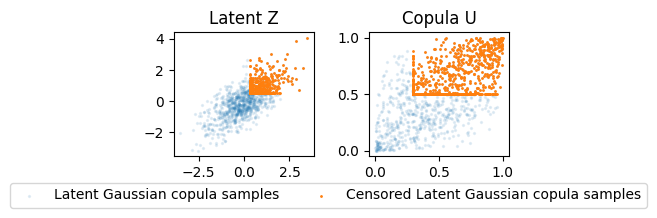

In [9]:
# generate censored Gaussian data for copula

latent_z = scs.multivariate_normal.rvs(mean=[0, 0], cov=[[1, 0.7], [0.7, 1]], size=1000)
copula_u = scs.norm.cdf(latent_z)
censor_lvl = np.array([0.3,0.5])
latent_z_censored = np.maximum(latent_z,censor_lvl)
copula_u_censored = np.maximum(copula_u,censor_lvl)
fig, axes = plt.subplots(1, 2, figsize=(4, 2))

axes[0].scatter(latent_z[:, 0], latent_z[:, 1], s=2,alpha=0.1, label='Latent Gaussian copula samples')
axes[0].scatter(latent_z_censored[:, 0], latent_z_censored[:, 1], s=1, label='Censored Latent Gaussian copula samples')
axes[0].set_title('Latent Z')

axes[1].scatter(copula_u[:, 0], copula_u[:, 1], s=2,alpha=0.1)
axes[1].scatter(copula_u_censored[:,0],copula_u_censored[:,1],s=1)
axes[1].set_title('Copula U')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=2)
plt.tight_layout()
plt.show()

In [10]:
# On the Gaussian Scale
def sample_Gauss_2d(n, cov):
    latent_z = scs.multivariate_normal.rvs(mean=np.zeros(cov.shape[0]), cov=cov, size=n)
    return latent_z

def sample_Gauss_2d_fixed_noise(n, noise, chol_cov):
    latent_z = noise @ chol_cov.T
    return latent_z
fixed_noise = scs.norm.rvs(size=(1000, 2))

cens_e_scores_per_rho = []
beta = 0.5
for i in tqdm(range(100)):
    rho = np.round((i+1)/101,2)
    chol_cov = np.linalg.cholesky([[1, rho], [rho, 1]])
    gauss2d_fixed_samples = sample_Gauss_2d_fixed_noise(1000, fixed_noise, chol_cov)
    gauss2d_fixed_samples_censored = np.maximum(gauss2d_fixed_samples,censor_lvl)
    gauss2d_samples = sample_Gauss_2d(1000, cov=np.array([[1, rho], [rho, 1]]))
    gauss2d_samples_censored = np.maximum(gauss2d_samples,censor_lvl)
    cens_e_scores_per_rho.append([Energy_Score(beta, torch.tensor(latent_z_censored), torch.tensor(gauss2d_samples_censored)),Energy_Score(beta, torch.tensor(latent_z_censored), torch.tensor(gauss2d_fixed_samples_censored)),rho])

# On the Copula Scale
def sample_Gauss_2d_copula(n, cov):
    latent_z = scs.multivariate_normal.rvs(mean=np.zeros(cov.shape[0]), cov=cov, size=n)
    return scs.norm.cdf(np.clip(latent_z, -7, 7))

def sample_Gauss_2d_fixed_noise_copula(n, noise, chol_cov):
    latent_z = noise @ chol_cov.T
    return scs.norm.cdf(np.clip(latent_z, -7, 7))
fixed_noise = scs.norm.rvs(size=(1000, 2))

cens_e_scores_per_rho_cop = []
beta = 0.5
for i in tqdm(range(100)):
    rho = np.round((i+1)/101,2)
    chol_cov = np.linalg.cholesky([[1, rho], [rho, 1]])
    cop2d_fixed_samples = sample_Gauss_2d_fixed_noise_copula(1000, fixed_noise, chol_cov)
    cop2d_fixed_samples_censored = np.maximum(cop2d_fixed_samples,censor_lvl)
    cop2d_samples = sample_Gauss_2d_copula(1000, cov=np.array([[1, rho], [rho, 1]]))
    cop2d_samples_censored = np.maximum(cop2d_samples,censor_lvl)
    cens_e_scores_per_rho_cop.append([Energy_Score(beta, torch.tensor(copula_u_censored), torch.tensor(cop2d_samples_censored)),Energy_Score(beta, torch.tensor(copula_u_censored), torch.tensor(cop2d_fixed_samples_censored)),rho])


100%|██████████| 100/100 [00:02<00:00, 34.90it/s]


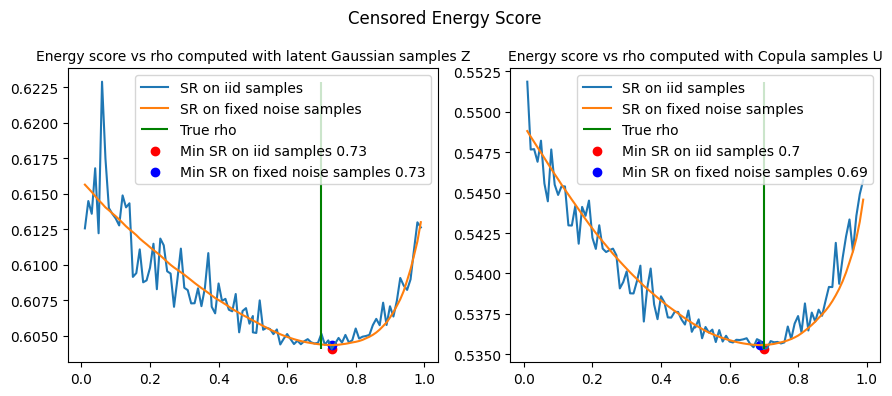

In [11]:

# Convert to numpy arrays
cens_e_scores_per_rho = np.array(cens_e_scores_per_rho)
cens_e_scores_per_rho_cop = np.array(cens_e_scores_per_rho_cop)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Plot for latent Gaussian samples Z
fig.suptitle('Censored Energy Score')

axes[0].set_title('Energy score vs rho computed with latent Gaussian samples Z', fontsize=10)
axes[0].plot(cens_e_scores_per_rho[:, 2], cens_e_scores_per_rho[:, 0], label='SR on iid samples')
axes[0].plot(cens_e_scores_per_rho[:, 2], cens_e_scores_per_rho[:, 1], label='SR on fixed noise samples')
axes[0].vlines(0.7, cens_e_scores_per_rho[:, 0:2].min(), cens_e_scores_per_rho[:, 0:2].max(), color='green', label='True rho')
axes[0].scatter(cens_e_scores_per_rho[np.argmin(cens_e_scores_per_rho[:, 0]), 2], cens_e_scores_per_rho[np.argmin(cens_e_scores_per_rho[:, 0]), 0], color='red', label=f'Min SR on iid samples {cens_e_scores_per_rho[np.argmin(cens_e_scores_per_rho[:, 0]), 2]}')
axes[0].scatter(cens_e_scores_per_rho[np.argmin(cens_e_scores_per_rho[:, 1]), 2], cens_e_scores_per_rho[np.argmin(cens_e_scores_per_rho[:, 1]), 1], color='blue', label=f'Min SR on fixed noise samples {cens_e_scores_per_rho[np.argmin(cens_e_scores_per_rho[:, 1]), 2]}')
axes[0].legend()

# Plot for Copula samples U
axes[1].set_title('Energy score vs rho computed with Copula samples U', fontsize=10)
axes[1].plot(cens_e_scores_per_rho_cop[:, 2], cens_e_scores_per_rho_cop[:, 0], label='SR on iid samples')
axes[1].plot(cens_e_scores_per_rho_cop[:, 2], cens_e_scores_per_rho_cop[:, 1], label='SR on fixed noise samples')
axes[1].vlines(0.7, cens_e_scores_per_rho_cop[:, 0:2].min(), cens_e_scores_per_rho_cop[:, 0:2].max(), color='green', label='True rho')
axes[1].scatter(cens_e_scores_per_rho_cop[np.argmin(cens_e_scores_per_rho_cop[:, 0]), 2], cens_e_scores_per_rho_cop[np.argmin(cens_e_scores_per_rho_cop[:, 0]), 0], color='red', label=f'Min SR on iid samples {cens_e_scores_per_rho_cop[np.argmin(cens_e_scores_per_rho_cop[:, 0]), 2]}')
axes[1].scatter(cens_e_scores_per_rho_cop[np.argmin(cens_e_scores_per_rho_cop[:, 1]), 2], cens_e_scores_per_rho_cop[np.argmin(cens_e_scores_per_rho_cop[:, 1]), 1], color='blue', label=f'Min SR on fixed noise samples {cens_e_scores_per_rho_cop[np.argmin(cens_e_scores_per_rho_cop[:, 1]), 2]}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 2D Gaussian with $\theta$ using a GPK 

In [2]:
from sklearn.metrics.pairwise import euclidean_distances 

locations = np.array([[0, 0], [10, 10]])
dist_matrix = euclidean_distances(locations, locations)
true_cov = Matern(length_scale=30, nu=2.5).__call__(dist_matrix)
dist_matrix,true_cov


(array([[ 0.        , 14.14213562],
        [14.14213562,  0.        ]]),
 array([[1.        , 0.72776274],
        [0.72776274, 1.        ]]))

### 2D Fully observed Gaussian copula inference of $\theta$ with GPK

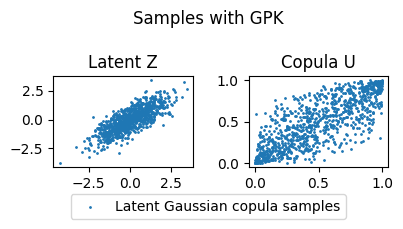

In [13]:
# generate Gaussian data for copula

latent_z = scs.multivariate_normal.rvs(mean=[0, 0], cov=true_cov, size=1000)
copula_u = scs.norm.cdf(latent_z)
fig, axes = plt.subplots(1, 2, figsize=(4, 2))

axes[0].scatter(latent_z[:, 0], latent_z[:, 1], s=1, label='Latent Gaussian copula samples')
axes[0].set_title('Latent Z')

axes[1].scatter(copula_u[:, 0], copula_u[:, 1], s=1)
axes[1].set_title('Copula U')

fig.legend(loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=2)
fig.suptitle('Samples with GPK')
plt.tight_layout()
plt.show()

In [14]:
# On the Gaussian Scale
def sample_Gauss_2d(n, cov):
    latent_z = scs.multivariate_normal.rvs(mean=np.zeros(cov.shape[0]), cov=cov, size=n)
    return latent_z

def sample_Gauss_2d_fixed_noise(n, noise, chol_cov):
    latent_z = noise @ chol_cov.T
    return latent_z
fixed_noise = scs.norm.rvs(size=(1000, 2))

e_scores_per_rho = []
beta = 0.5
for i in tqdm(range(99)):
    estimated_cov = Matern(length_scale=i+1, nu=3.5).__call__(dist_matrix)
    chol_cov = np.linalg.cholesky(estimated_cov)
    gauss2d_fixed_samples = sample_Gauss_2d_fixed_noise(1000, fixed_noise, chol_cov)
    gauss2d_samples = sample_Gauss_2d(1000, cov=estimated_cov)
    e_scores_per_rho.append([Energy_Score(beta, torch.tensor(latent_z), torch.tensor(gauss2d_samples)),Energy_Score(beta, torch.tensor(latent_z), torch.tensor(gauss2d_fixed_samples)),i+1])

# On the Copula Scale
def sample_Gauss_2d_copula(n, cov):
    latent_z = scs.multivariate_normal.rvs(mean=np.zeros(cov.shape[0]), cov=cov, size=n)
    return scs.norm.cdf(np.clip(latent_z, -7, 7))

def sample_Gauss_2d_fixed_noise_copula(n, noise, chol_cov):
    latent_z = noise @ chol_cov.T
    return scs.norm.cdf(np.clip(latent_z, -7, 7))
fixed_noise = scs.norm.rvs(size=(1000, 2))

e_scores_per_rho_cop = []
beta = 0.5
for i in tqdm(range(100)):
    estimated_cov = Matern(length_scale=i+1, nu=3.5).__call__(dist_matrix)
    chol_cov = np.linalg.cholesky(estimated_cov)
    cop2d_fixed_samples = sample_Gauss_2d_fixed_noise_copula(1000, fixed_noise, chol_cov)
    cop2d_samples = sample_Gauss_2d_copula(1000, cov=estimated_cov)
    e_scores_per_rho_cop.append([Energy_Score(beta, torch.tensor(copula_u), torch.tensor(cop2d_samples)),Energy_Score(beta, torch.tensor(copula_u), torch.tensor(cop2d_fixed_samples)),i+1])


100%|██████████| 100/100 [00:02<00:00, 37.17it/s]


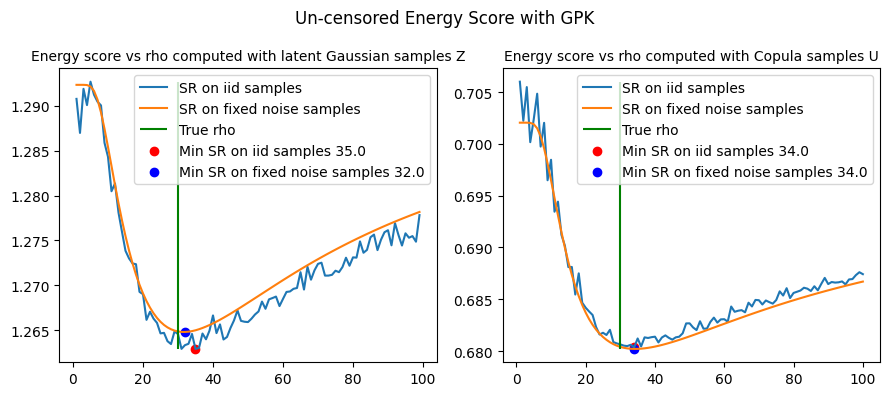

In [15]:
e_scores_per_rho = np.array(e_scores_per_rho)
e_scores_per_rho_cop = np.array(e_scores_per_rho_cop)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Plot for latent Gaussian samples Z
axes[0].set_title('Energy score vs rho computed with latent Gaussian samples Z',fontsize=10)
axes[0].plot(e_scores_per_rho[:, 2], e_scores_per_rho[:, 0], label='SR on iid samples')
axes[0].plot(e_scores_per_rho[:, 2], e_scores_per_rho[:, 1], label='SR on fixed noise samples')
axes[0].vlines(30, e_scores_per_rho[:, 0:2].min(), e_scores_per_rho[:, 0:2].max(), color='green', label='True rho')
axes[0].scatter(e_scores_per_rho[np.argmin(e_scores_per_rho[:, 0]), 2], e_scores_per_rho[np.argmin(e_scores_per_rho[:, 0]), 0], color='red', label=f'Min SR on iid samples {e_scores_per_rho[np.argmin(e_scores_per_rho[:, 0]), 2]}')
axes[0].scatter(e_scores_per_rho[np.argmin(e_scores_per_rho[:, 1]), 2], e_scores_per_rho[np.argmin(e_scores_per_rho[:, 1]), 1], color='blue', label=f'Min SR on fixed noise samples {e_scores_per_rho[np.argmin(e_scores_per_rho[:, 1]), 2]}')
axes[0].legend()

# Plot for Copula samples U
axes[1].set_title('Energy score vs rho computed with Copula samples U',fontsize=10)
axes[1].plot(e_scores_per_rho_cop[:, 2], e_scores_per_rho_cop[:, 0], label='SR on iid samples')
axes[1].plot(e_scores_per_rho_cop[:, 2], e_scores_per_rho_cop[:, 1], label='SR on fixed noise samples')
axes[1].vlines(30, e_scores_per_rho_cop[:, 0:2].min(), e_scores_per_rho_cop[:, 0:2].max(), color='green', label='True rho')
axes[1].scatter(e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 0]), 2], e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 0]), 0], color='red', label=f'Min SR on iid samples {e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 0]), 2]}')
axes[1].scatter(e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 1]), 2], e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 1]), 1], color='blue', label=f'Min SR on fixed noise samples {e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 1]), 2]}')
axes[1].legend()

fig.suptitle('Un-censored Energy Score with GPK')
plt.tight_layout()
plt.show()

### 2D Censored Gaussian copula inference of $\theta$ with GPK

In [16]:
# generate censored Gaussian data for copula

latent_z = scs.multivariate_normal.rvs(mean=[0, 0], cov=true_cov, size=1000)
copula_u = scs.norm.cdf(latent_z)
censor_lvl = np.array([0.3,0.5])
latent_z_censored = np.maximum(latent_z,censor_lvl)
copula_u_censored = np.maximum(copula_u,censor_lvl)

In [17]:
# On the Gaussian Scale
def sample_Gauss_2d(n, cov):
    latent_z = scs.multivariate_normal.rvs(mean=np.zeros(cov.shape[0]), cov=cov, size=n)
    return latent_z

def sample_Gauss_2d_fixed_noise(n, noise, chol_cov):
    latent_z = noise @ chol_cov.T
    return latent_z
fixed_noise = scs.norm.rvs(size=(1000, 2))

cens_e_scores_per_rho = []
beta = 0.5
for i in tqdm(range(99)):
    estimated_cov = Matern(length_scale=i+1, nu=3.5).__call__(dist_matrix)
    chol_cov = np.linalg.cholesky(estimated_cov)
    gauss2d_fixed_samples = sample_Gauss_2d_fixed_noise(1000, fixed_noise, chol_cov)
    censored_gauss2d_fixed_samples = np.maximum(gauss2d_fixed_samples,censor_lvl)
    gauss2d_samples = sample_Gauss_2d(1000, cov=estimated_cov)
    censored_gauss2d_samples = np.maximum(gauss2d_samples,censor_lvl)
    cens_e_scores_per_rho.append([Energy_Score(beta, torch.tensor(latent_z_censored), torch.tensor(censored_gauss2d_samples)),Energy_Score(beta, torch.tensor(latent_z_censored), torch.tensor(censored_gauss2d_fixed_samples)),i+1])

# On the Copula Scale
def sample_Gauss_2d_copula(n, cov):
    latent_z = scs.multivariate_normal.rvs(mean=np.zeros(cov.shape[0]), cov=cov, size=n)
    return scs.norm.cdf(np.clip(latent_z, -7, 7))

def sample_Gauss_2d_fixed_noise_copula(n, noise, chol_cov):
    latent_z = noise @ chol_cov.T
    return scs.norm.cdf(np.clip(latent_z, -7, 7))
fixed_noise = scs.norm.rvs(size=(1000, 2))

cens_e_scores_per_rho_cop = []
beta = 0.5
for i in tqdm(range(100)):
    estimated_cov = Matern(length_scale=i+1, nu=3.5).__call__(dist_matrix)
    chol_cov = np.linalg.cholesky(estimated_cov)
    cop2d_fixed_samples = sample_Gauss_2d_fixed_noise_copula(1000, fixed_noise, chol_cov)
    censored_cop2d_fixed_samples = np.maximum(cop2d_fixed_samples,censor_lvl)
    cop2d_samples = sample_Gauss_2d_copula(1000, cov=estimated_cov)
    censored_cop2d_samples = np.maximum(cop2d_samples,censor_lvl)
    cens_e_scores_per_rho_cop.append([Energy_Score(beta, torch.tensor(copula_u_censored), torch.tensor(censored_cop2d_samples)),Energy_Score(beta, torch.tensor(copula_u_censored), torch.tensor(censored_cop2d_fixed_samples)),i+1])


100%|██████████| 100/100 [00:02<00:00, 33.75it/s]


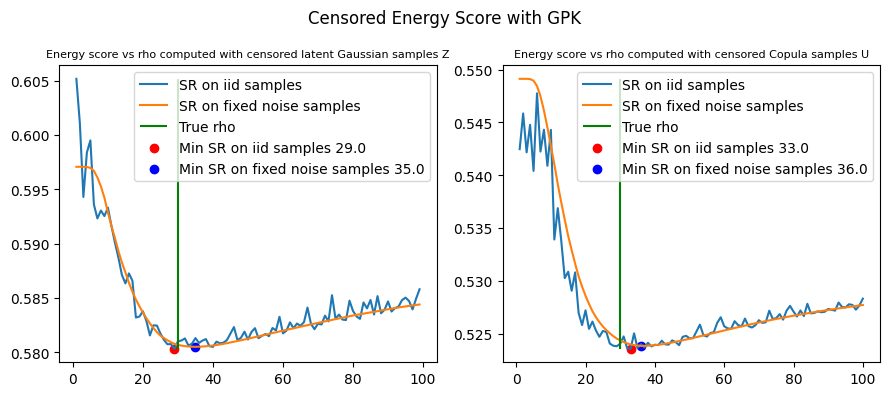

In [18]:

# Convert to numpy arrays
cens_e_scores_per_rho = np.array(cens_e_scores_per_rho)
cens_e_scores_per_rho_cop = np.array(cens_e_scores_per_rho_cop)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Plot for latent Gaussian samples Z
fig.suptitle('Censored Energy Score with GPK')

axes[0].set_title('Energy score vs rho computed with censored latent Gaussian samples Z', fontsize=8)
axes[0].plot(cens_e_scores_per_rho[:, 2], cens_e_scores_per_rho[:, 0], label='SR on iid samples')
axes[0].plot(cens_e_scores_per_rho[:, 2], cens_e_scores_per_rho[:, 1], label='SR on fixed noise samples')
axes[0].vlines(30, cens_e_scores_per_rho[:, 0:2].min(), cens_e_scores_per_rho[:, 0:2].max(), color='green', label='True rho')
axes[0].scatter(cens_e_scores_per_rho[np.argmin(cens_e_scores_per_rho[:, 0]), 2], cens_e_scores_per_rho[np.argmin(cens_e_scores_per_rho[:, 0]), 0], color='red', label=f'Min SR on iid samples {cens_e_scores_per_rho[np.argmin(cens_e_scores_per_rho[:, 0]), 2]}')
axes[0].scatter(cens_e_scores_per_rho[np.argmin(cens_e_scores_per_rho[:, 1]), 2], cens_e_scores_per_rho[np.argmin(cens_e_scores_per_rho[:, 1]), 1], color='blue', label=f'Min SR on fixed noise samples {cens_e_scores_per_rho[np.argmin(cens_e_scores_per_rho[:, 1]), 2]}')
axes[0].legend()

# Plot for Copula samples U
axes[1].set_title('Energy score vs rho computed with censored Copula samples U', fontsize=8)
axes[1].plot(cens_e_scores_per_rho_cop[:, 2], cens_e_scores_per_rho_cop[:, 0], label='SR on iid samples')
axes[1].plot(cens_e_scores_per_rho_cop[:, 2], cens_e_scores_per_rho_cop[:, 1], label='SR on fixed noise samples')
axes[1].vlines(30, cens_e_scores_per_rho_cop[:, 0:2].min(), cens_e_scores_per_rho_cop[:, 0:2].max(), color='green', label='True rho')
axes[1].scatter(cens_e_scores_per_rho_cop[np.argmin(cens_e_scores_per_rho_cop[:, 0]), 2], cens_e_scores_per_rho_cop[np.argmin(cens_e_scores_per_rho_cop[:, 0]), 0], color='red', label=f'Min SR on iid samples {cens_e_scores_per_rho_cop[np.argmin(cens_e_scores_per_rho_cop[:, 0]), 2]}')
axes[1].scatter(cens_e_scores_per_rho_cop[np.argmin(cens_e_scores_per_rho_cop[:, 1]), 2], cens_e_scores_per_rho_cop[np.argmin(cens_e_scores_per_rho_cop[:, 1]), 1], color='blue', label=f'Min SR on fixed noise samples {cens_e_scores_per_rho_cop[np.argmin(cens_e_scores_per_rho_cop[:, 1]), 2]}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 2D Gaussian with $\theta, a$ using a GPK (ILL-DEFINED IN 2D)

In [19]:
from sklearn.metrics.pairwise import euclidean_distances 

locations = np.array([[0, 0], [10, 10]])
dist_matrix = euclidean_distances(locations, locations)
topos = np.array([[100], [10]]) # chosen to be about 1/70 of the distance matrix
topo_matrix = euclidean_distances(topos, topos)
true_cov = Matern(length_scale=30, nu=3.5).__call__(dist_matrix+ 0.014*topo_matrix)
latent_z = scs.multivariate_normal.rvs(mean=[0, 0], cov=true_cov, size=5000)
copula_u = scs.norm.cdf(latent_z)
true_cov

array([[1.        , 0.71322114],
       [0.71322114, 1.        ]])

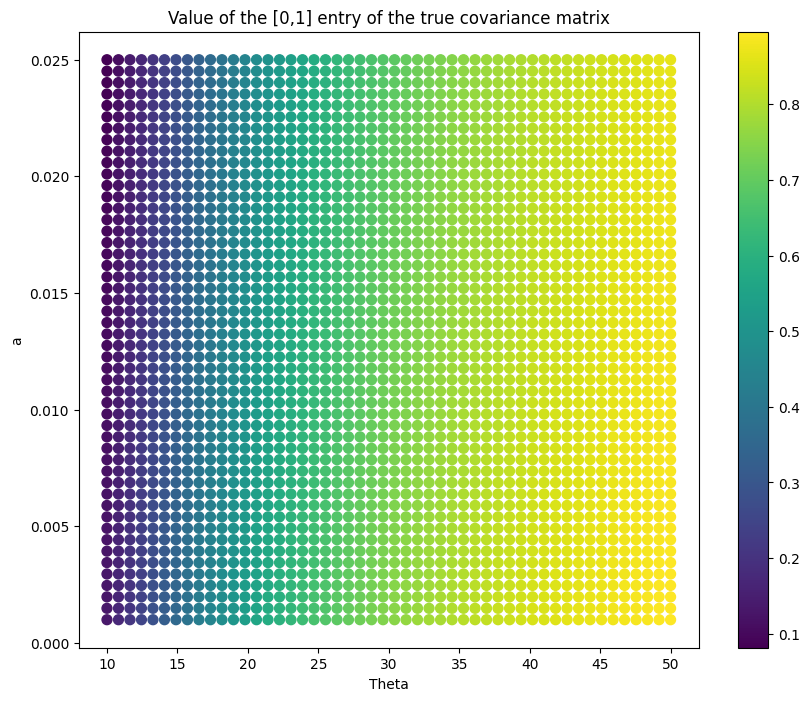

In [20]:
# Define the range of theta and a values
theta_vals = np.linspace(10, 50, 50)
a_vals = np.linspace(0.001, 0.025, 50)

# Initialize the matrix to store the [0,1] entry of true_cov
true_cov_entries = np.zeros((len(theta_vals), len(a_vals)))

# Calculate the [0,1] entry of true_cov for each combination of theta and a
for i, theta_ in enumerate(theta_vals):
    for j, a_ in enumerate(a_vals):
        true_cov = Matern(length_scale=theta_, nu=3.5).__call__(dist_matrix + a_ * topo_matrix)
        true_cov_entries[i, j] = true_cov[1,0]

# Create the contour plot
theta_vals, a_vals = np.meshgrid(theta_vals, a_vals)
plt.figure(figsize=(10, 8))
true_cov_value = 0.71    
contour = plt.scatter(theta_vals, a_vals, c=true_cov_entries.T#np.sqrt(abs(true_cov_entries.T-true_cov_value))
                      , cmap='viridis', s=50)
plt.colorbar(contour)
plt.title(f'Value of the [0,1] entry of the true covariance matrix')
#plt.title(f'sqrt(abs(GPK(dist+ a*topo|theta) - true rho value={true_cov_value}))')
plt.xlabel('Theta')
plt.ylabel('a')
plt.show()

In [21]:
# On the Gaussian Scale
def sample_Gauss_2d(n, cov):
    latent_z = scs.multivariate_normal.rvs(mean=np.zeros(cov.shape[0]), cov=cov, size=n)
    return latent_z

def sample_Gauss_2d_fixed_noise(n, noise, chol_cov):
    latent_z = noise @ chol_cov.T
    return latent_z
fixed_noise = scs.norm.rvs(size=(1000, 2))

e_scores_per_rho = []
beta = 0.5
for theta_ in tqdm(np.linspace(10,50,20)):
    for a_ in np.linspace(0.001,0.025,20):
        estimated_cov = Matern(length_scale=theta_, nu=3.5).__call__(dist_matrix+a_*topo_matrix)
        chol_cov = np.linalg.cholesky(estimated_cov)
        gauss2d_fixed_samples = sample_Gauss_2d_fixed_noise(1000, fixed_noise, chol_cov)
        gauss2d_samples = sample_Gauss_2d(1000, cov=estimated_cov)
        e_scores_per_rho.append([Energy_Score(beta, torch.tensor(latent_z), torch.tensor(gauss2d_samples)),Energy_Score(beta, torch.tensor(latent_z), torch.tensor(gauss2d_fixed_samples)),theta_,a_])

# On the Copula Scale
def sample_Gauss_2d_copula(n, cov):
    latent_z = scs.multivariate_normal.rvs(mean=np.zeros(cov.shape[0]), cov=cov, size=n)
    return scs.norm.cdf(np.clip(latent_z, -7, 7))

def sample_Gauss_2d_fixed_noise_copula(n, noise, chol_cov):
    latent_z = noise @ chol_cov.T
    return scs.norm.cdf(np.clip(latent_z, -7, 7))
fixed_noise = scs.norm.rvs(size=(1000, 2))

e_scores_per_rho_cop = []
beta = 0.5
for theta_ in tqdm(np.linspace(10,50,20)):
    for a_ in np.linspace(0.001,0.025,20):
        estimated_cov = Matern(length_scale=theta_, nu=3.5).__call__(dist_matrix+a_*topo_matrix)
        chol_cov = np.linalg.cholesky(estimated_cov)
        cop2d_fixed_samples = sample_Gauss_2d_fixed_noise_copula(1000, fixed_noise, chol_cov)
        cop2d_samples = sample_Gauss_2d_copula(1000, cov=estimated_cov)
        e_scores_per_rho_cop.append([Energy_Score(beta, torch.tensor(copula_u), torch.tensor(cop2d_samples)),Energy_Score(beta, torch.tensor(copula_u), torch.tensor(cop2d_fixed_samples)),theta_,a_])


100%|██████████| 20/20 [00:37<00:00,  1.89s/it]


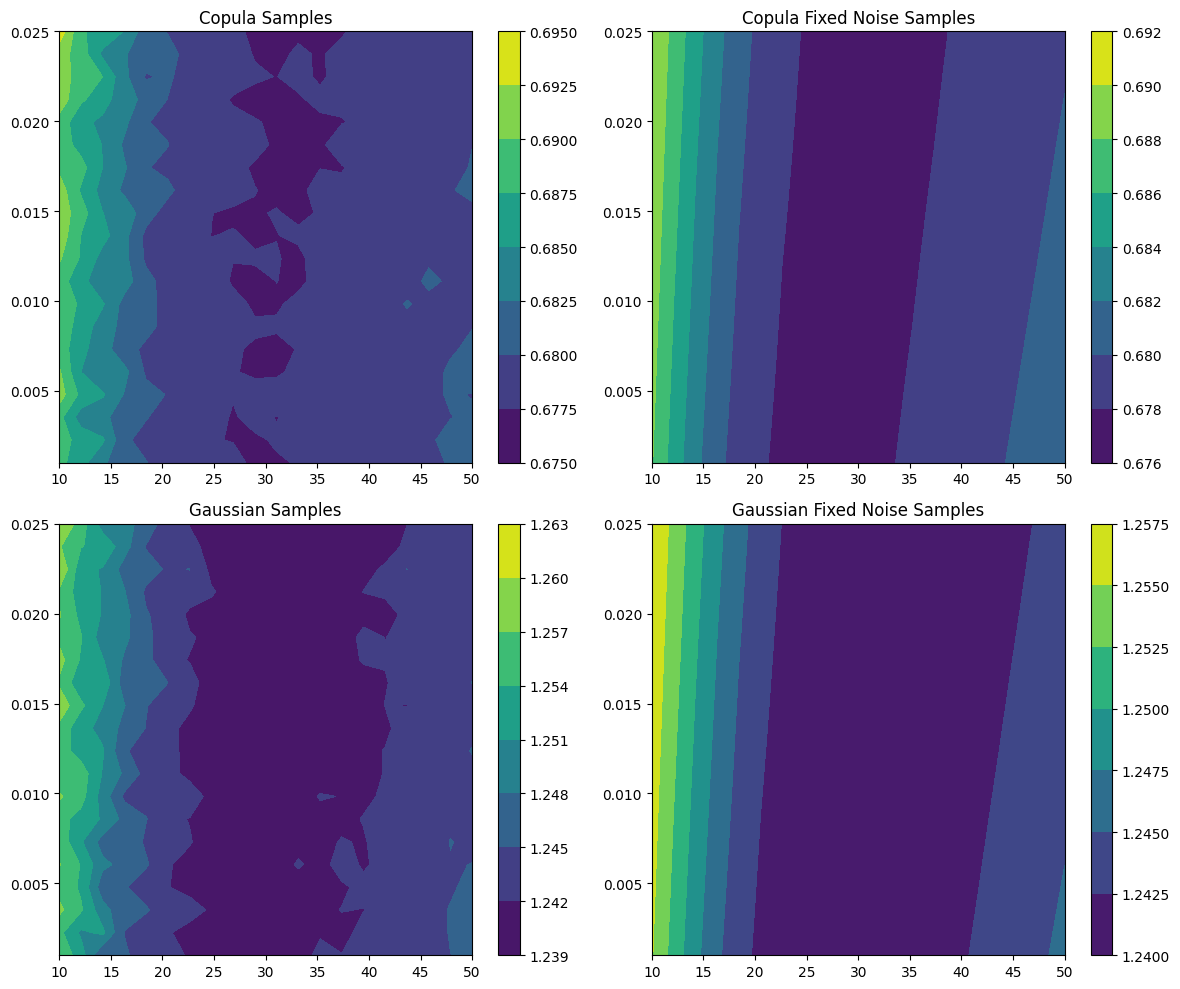

In [22]:
# Extracting data for plotting
theta_vals = np.linspace(10,50,20)
a_vals = np.linspace(0.001,0.025,20)
theta_vals, a_vals = np.meshgrid(theta_vals, a_vals)
e_scores_gauss_samples = np.array([score[0] for score in e_scores_per_rho]).reshape(20, 20)
e_scores_gauss_fixed_samples = np.array([score[1] for score in e_scores_per_rho]).reshape(20, 20)
e_scores_cop_samples = np.array([score[0] for score in e_scores_per_rho_cop]).reshape(20, 20)
e_scores_cop_fixed_samples = np.array([score[1] for score in e_scores_per_rho_cop]).reshape(20, 20)

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

contour1 = axs[0, 0].contourf(theta_vals, a_vals, e_scores_cop_samples.T, cmap='viridis')
axs[0, 0].set_title('Copula Samples')
fig.colorbar(contour1, ax=axs[0, 0])

contour2 = axs[0, 1].contourf(theta_vals, a_vals, e_scores_cop_fixed_samples.T, cmap='viridis')
axs[0, 1].set_title('Copula Fixed Noise Samples')
fig.colorbar(contour2, ax=axs[0, 1])

contour3 = axs[1, 0].contourf(theta_vals, a_vals, e_scores_gauss_samples.T, cmap='viridis')
axs[1, 0].set_title('Gaussian Samples')
fig.colorbar(contour3, ax=axs[1, 0])

contour4 = axs[1, 1].contourf(theta_vals, a_vals, e_scores_gauss_fixed_samples.T, cmap='viridis')
axs[1, 1].set_title('Gaussian Fixed Noise Samples')
fig.colorbar(contour4, ax=axs[1, 1])

plt.tight_layout()
plt.show()

# 4D Gaussian SR inference

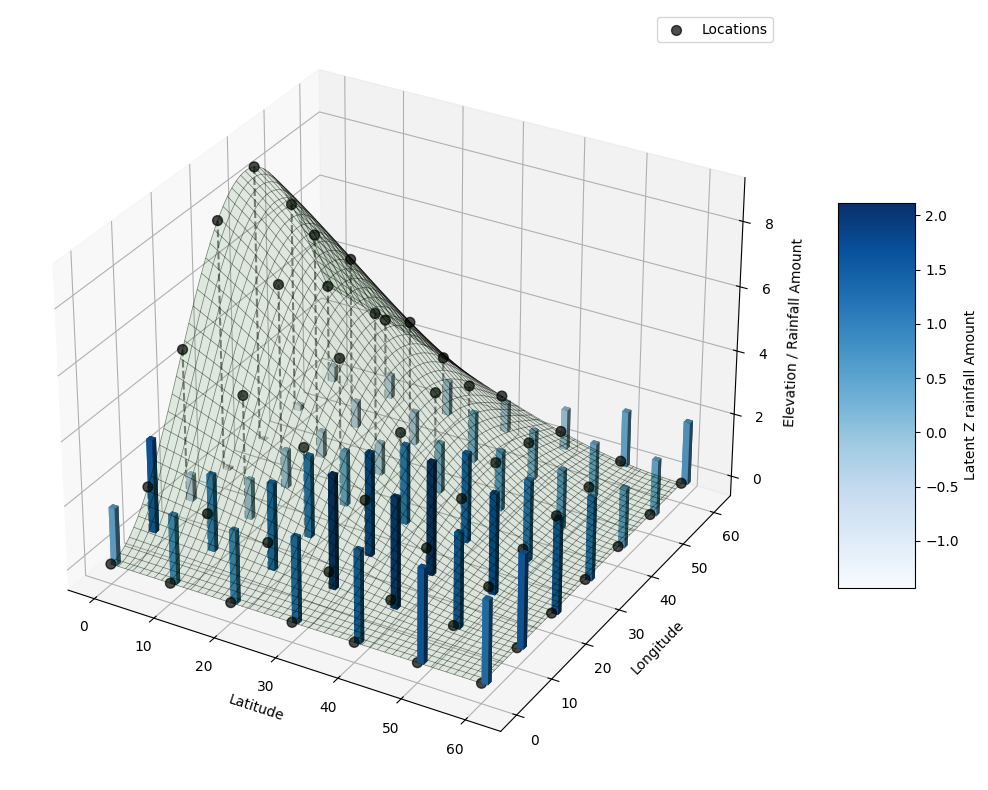

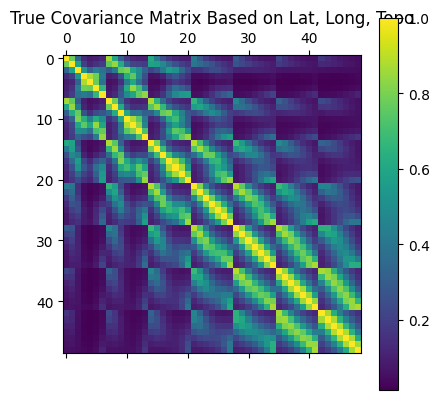

In [84]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.gaussian_process.kernels import Matern
import scipy.stats as scs

# Parameter to define the number of locations (e.g., 3 for a 3x3 grid)
loc_nb = 7

# Generate the locations as a grid from 0 by increments of 10 in each direction
x_coords = np.arange(0, loc_nb * 10, 10)
y_coords = np.arange(0, loc_nb * 10, 10)
locations = np.array([[x, y] for x in x_coords for y in y_coords])

# Define the surface equation
surface_eq = lambda x, y: 10*(np.sin(x/50-1.2)*np.sin(-y/24))**2 

# Calculate the topographies based on the surface equation
topos = surface_eq(locations[:, 0], locations[:, 1])
distances = np.hstack((locations, 7 * topos.reshape(-1, 1)))
dist_matrix = euclidean_distances(distances, distances)
true_cov = Matern(length_scale=100, nu=3.5).__call__(dist_matrix)

latent_z = scs.multivariate_normal.rvs(mean=np.zeros(true_cov.shape[0]), cov=true_cov, size=1000)
copula_u = scs.norm.cdf(latent_z)

# Prepare data for 3D plot
x = locations[:, 0]
y = locations[:, 1]
z = topos
rainfall = latent_z[0]

# Create a 3D scatter plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the points as rectangles representing rainfall amount
for i in range(len(x)):
    ax.bar3d(x[i], y[i], 0, 1, 1, rainfall[i] - rainfall.min(), color=plt.cm.Blues((rainfall[i] - rainfall.min()) / (rainfall.max() - rainfall.min())))
ax.scatter(x, y, z, color='black', s=50, label='Locations', alpha=0.7)
for i in range(len(x)):
    ax.plot([x[i], x[i]], [y[i], y[i]], [0, z[i]], color='grey', linestyle='--')

# Create a grid for the surface plot
X, Y = np.meshgrid(np.linspace(0, (loc_nb - 1) * 10, 100), np.linspace(0, (loc_nb - 1) * 10, 100))
Z = surface_eq(X, Y)

# Plot the surface
ax.plot_surface(X, Y, Z, color='g', alpha=0.1)

# Add wireframe lines on the surface
ax.plot_wireframe(X, Y, Z, color='k', linewidth=0.5, alpha=0.5)

# Add colorbar for rainfall
mappable = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=rainfall.min(), vmax=rainfall.max()))
mappable.set_array([])
fig.colorbar(mappable, ax=ax, shrink=0.5, aspect=5, label='Latent Z rainfall Amount')

# Set labels
#ax.set_title('3D Surface Plot with Rainfall Amount Rectangles')
ax.set_xlabel('Latitude')
ax.set_ylabel('Longitude')
ax.set_zlabel('Elevation / Rainfall Amount')
plt.legend()
plt.tight_layout()
plt.show()

plt.matshow(true_cov)
plt.colorbar()
plt.title('True Covariance Matrix Based on Lat, Long, Topo')
plt.show()

## 4D uncensored Gaussian copula inference of $\rho$ directly

In [25]:
# On the Gaussian Scale

def sample_Gauss_fixed_noise(noise, chol_cov):
    latent_z = noise @ chol_cov.T
    return latent_z
fixed_noise = scs.norm.rvs(size=(1000, 16))

e_scores_per_rho = []
beta = 0.5
for theta_ in tqdm(np.linspace(30,70,20)):
    #for a_ in np.linspace(0.1,1.3,20):
        estimated_distances = np.hstack((locations, 0.7 * topos.reshape(-1, 1)))
        estimated_dist_matrix = euclidean_distances(estimated_distances, estimated_distances)
        estimated_cov = Matern(length_scale=theta_, nu=3.5).__call__(estimated_dist_matrix)
        chol_cov = np.linalg.cholesky(estimated_cov)
        gauss_fixed_samples = sample_Gauss_fixed_noise(fixed_noise, chol_cov)
        gauss_samples = scs.multivariate_normal.rvs(mean=np.zeros(estimated_cov.shape[0]), cov=estimated_cov, size=1000)
        e_scores_per_rho.append([Energy_Score(beta, torch.tensor(latent_z), torch.tensor(gauss_samples)),Energy_Score(beta, torch.tensor(latent_z), torch.tensor(gauss_fixed_samples)),theta_,a_])

# On the Copula Scale


e_scores_per_rho_cop = []
beta = 0.5
for theta_ in tqdm(np.linspace(30,70,20)):
    #for a_ in np.linspace(0.001,0.025,20):
        estimated_distances = np.hstack((locations, 0.7 * topos.reshape(-1, 1)))
        estimated_dist_matrix = euclidean_distances(estimated_distances, estimated_distances)
        estimated_cov = Matern(length_scale=theta_, nu=3.5).__call__(estimated_dist_matrix)        
        chol_cov = np.linalg.cholesky(estimated_cov)
        cop_fixed_samples = scs.norm.cdf(sample_Gauss_fixed_noise(fixed_noise, chol_cov))
        cop_samples = scs.norm.cdf(scs.multivariate_normal.rvs(mean=np.zeros(estimated_cov.shape[0]), cov=estimated_cov, size=1000))
        e_scores_per_rho_cop.append([Energy_Score(beta, torch.tensor(copula_u), torch.tensor(cop_samples)),Energy_Score(beta, torch.tensor(copula_u), torch.tensor(cop_fixed_samples)),theta_,a_])


  0%|          | 0/20 [00:00<?, ?it/s]


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 49 is different from 16)

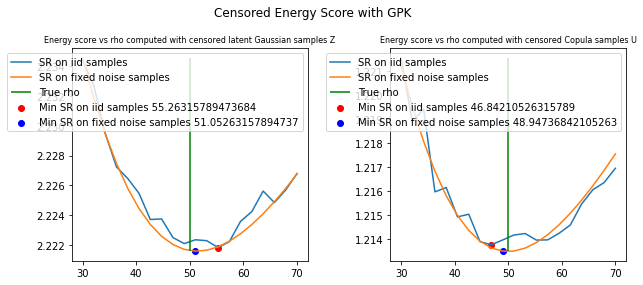

In [ ]:
# Convert to numpy arrays
e_scores_per_rho = np.array(e_scores_per_rho)
e_scores_per_rho_cop = np.array(e_scores_per_rho_cop)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
fig.suptitle('Censored Energy Score with GPK')

# Plot for latent Gaussian samples Z
axes[0].set_title('Energy score vs rho computed with censored latent Gaussian samples Z', fontsize=8)
axes[0].plot(e_scores_per_rho[:, 2], e_scores_per_rho[:, 0], label='SR on iid samples')
axes[0].plot(e_scores_per_rho[:, 2], e_scores_per_rho[:, 1], label='SR on fixed noise samples')
axes[0].vlines(50, e_scores_per_rho[:, 0:2].min(), e_scores_per_rho[:, 0:2].max(), color='green', label='True rho')
axes[0].scatter(e_scores_per_rho[np.argmin(e_scores_per_rho[:, 0]), 2], e_scores_per_rho[np.argmin(e_scores_per_rho[:, 0]), 0], color='red', label=f'Min SR on iid samples {e_scores_per_rho[np.argmin(e_scores_per_rho[:, 0]), 2]}')
axes[0].scatter(e_scores_per_rho[np.argmin(e_scores_per_rho[:, 1]), 2], e_scores_per_rho[np.argmin(e_scores_per_rho[:, 1]), 1], color='blue', label=f'Min SR on fixed noise samples {e_scores_per_rho[np.argmin(e_scores_per_rho[:, 1]), 2]}')
axes[0].legend()

# Plot for Copula samples U
axes[1].set_title('Energy score vs rho computed with censored Copula samples U', fontsize=8)
axes[1].plot(e_scores_per_rho_cop[:, 2], e_scores_per_rho_cop[:, 0], label='SR on iid samples')
axes[1].plot(e_scores_per_rho_cop[:, 2], e_scores_per_rho_cop[:, 1], label='SR on fixed noise samples')
axes[1].vlines(50, e_scores_per_rho_cop[:, 0:2].min(), e_scores_per_rho_cop[:, 0:2].max(), color='green', label='True rho')
axes[1].scatter(e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 0]), 2], e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 0]), 0], color='red', label=f'Min SR on iid samples {e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 0]), 2]}')
axes[1].scatter(e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 1]), 2], e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 1]), 1], color='blue', label=f'Min SR on fixed noise samples {e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 1]), 2]}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4D censored Gaussian copula inference of $\rho$ directly

In [26]:
censor_lvl = np.random.uniform(0,1,7*7)
latent_z_censored = np.maximum(latent_z,scs.norm.ppf(censor_lvl))
copula_u_censored = np.maximum(copula_u,(censor_lvl))

In [ ]:
# On the Gaussian Scale

def sample_Gauss_fixed_noise(noise, chol_cov):
    latent_z = noise @ chol_cov.T
    return latent_z
fixed_noise = scs.norm.rvs(size=(1000, 16))

e_scores_per_rho = []
beta = 0.5
for theta_ in tqdm(np.linspace(30,70,20)):
    #for a_ in np.linspace(0.1,1.3,20):
        estimated_distances = np.hstack((locations, 0.7 * topos.reshape(-1, 1)))
        estimated_dist_matrix = euclidean_distances(estimated_distances, estimated_distances)
        estimated_cov = Matern(length_scale=theta_, nu=3.5).__call__(estimated_dist_matrix)
        chol_cov = np.linalg.cholesky(estimated_cov)
        gauss_fixed_samples = sample_Gauss_fixed_noise(fixed_noise, chol_cov)
        gauss_samples = scs.multivariate_normal.rvs(mean=np.zeros(estimated_cov.shape[0]), cov=estimated_cov, size=1000)
        e_scores_per_rho.append([Energy_Score(beta, torch.tensor(latent_z_censored), torch.tensor(np.maximum(gauss_samples,scs.norm.ppf(censor_lvl)))),Energy_Score(beta, torch.tensor(latent_z_censored), torch.tensor(np.maximum(gauss_fixed_samples,scs.norm.ppf(censor_lvl)))),theta_,a_])

# On the Copula Scale


e_scores_per_rho_cop = []
beta = 0.5
for theta_ in tqdm(np.linspace(30,70,20)):
    #for a_ in np.linspace(0.001,0.025,20):
        estimated_distances = np.hstack((locations, 0.7 * topos.reshape(-1, 1)))
        estimated_dist_matrix = euclidean_distances(estimated_distances, estimated_distances)
        estimated_cov = Matern(length_scale=theta_, nu=3.5).__call__(estimated_dist_matrix)        
        chol_cov = np.linalg.cholesky(estimated_cov)
        cop_fixed_samples = scs.norm.cdf(sample_Gauss_fixed_noise(fixed_noise, chol_cov))
        cop_samples = scs.norm.cdf(scs.multivariate_normal.rvs(mean=np.zeros(estimated_cov.shape[0]), cov=estimated_cov, size=1000))
        e_scores_per_rho_cop.append([Energy_Score(beta, torch.tensor(copula_u_censored), torch.tensor(np.maximum(cop_samples,censor_lvl))),Energy_Score(beta, torch.tensor(copula_u_censored), torch.tensor(np.maximum(cop_fixed_samples,censor_lvl))),theta_,a_])


100%|██████████| 20/20 [00:04<00:00,  4.95it/s]


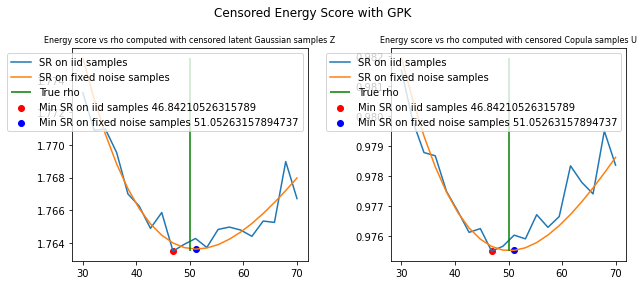

In [ ]:
# Convert to numpy arrays
e_scores_per_rho = np.array(e_scores_per_rho)
e_scores_per_rho_cop = np.array(e_scores_per_rho_cop)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
fig.suptitle('Censored Energy Score with GPK')

# Plot for latent Gaussian samples Z
axes[0].set_title('Energy score vs rho computed with censored latent Gaussian samples Z', fontsize=8)
axes[0].plot(e_scores_per_rho[:, 2], e_scores_per_rho[:, 0], label='SR on iid samples')
axes[0].plot(e_scores_per_rho[:, 2], e_scores_per_rho[:, 1], label='SR on fixed noise samples')
axes[0].vlines(50, e_scores_per_rho[:, 0:2].min(), e_scores_per_rho[:, 0:2].max(), color='green', label='True rho')
axes[0].scatter(e_scores_per_rho[np.argmin(e_scores_per_rho[:, 0]), 2], e_scores_per_rho[np.argmin(e_scores_per_rho[:, 0]), 0], color='red', label=f'Min SR on iid samples {e_scores_per_rho[np.argmin(e_scores_per_rho[:, 0]), 2]}')
axes[0].scatter(e_scores_per_rho[np.argmin(e_scores_per_rho[:, 1]), 2], e_scores_per_rho[np.argmin(e_scores_per_rho[:, 1]), 1], color='blue', label=f'Min SR on fixed noise samples {e_scores_per_rho[np.argmin(e_scores_per_rho[:, 1]), 2]}')
axes[0].legend()

# Plot for Copula samples U
axes[1].set_title('Energy score vs rho computed with censored Copula samples U', fontsize=8)
axes[1].plot(e_scores_per_rho_cop[:, 2], e_scores_per_rho_cop[:, 0], label='SR on iid samples')
axes[1].plot(e_scores_per_rho_cop[:, 2], e_scores_per_rho_cop[:, 1], label='SR on fixed noise samples')
axes[1].vlines(50, e_scores_per_rho_cop[:, 0:2].min(), e_scores_per_rho_cop[:, 0:2].max(), color='green', label='True rho')
axes[1].scatter(e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 0]), 2], e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 0]), 0], color='red', label=f'Min SR on iid samples {e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 0]), 2]}')
axes[1].scatter(e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 1]), 2], e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 1]), 1], color='blue', label=f'Min SR on fixed noise samples {e_scores_per_rho_cop[np.argmin(e_scores_per_rho_cop[:, 1]), 2]}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4D uncensored Gaussian copula inference of $\theta, a$ jointly

In [ ]:
# On the Gaussian Scale

def sample_Gauss_fixed_noise(noise, chol_cov):
    latent_z = noise @ chol_cov.T
    return latent_z
fixed_noise = scs.norm.rvs(size=(1000, 49))

e_scores_per_rho = []
beta = 0.5
for theta_ in tqdm(np.linspace(50,200,20)):
    for a_ in np.linspace(0.1,15,10):
        estimated_distances = np.hstack((locations, a_ * topos.reshape(-1, 1)))
        estimated_dist_matrix = euclidean_distances(estimated_distances, estimated_distances)
        estimated_cov = Matern(length_scale=theta_, nu=3.5).__call__(estimated_dist_matrix)
        chol_cov = np.linalg.cholesky(estimated_cov)
        gauss_fixed_samples = sample_Gauss_fixed_noise(fixed_noise, chol_cov)
        gauss_samples = scs.multivariate_normal.rvs(mean=np.zeros(estimated_cov.shape[0]), cov=estimated_cov, size=1000)
        e_scores_per_rho.append([Energy_Score(beta, torch.tensor(latent_z), torch.tensor(gauss_samples)),Energy_Score(beta, torch.tensor(latent_z), torch.tensor(gauss_fixed_samples)),theta_,a_])

# On the Copula Scale


e_scores_per_rho_cop = []
beta = 0.5
for theta_ in tqdm(np.linspace(50,2000,20)):
    for a_ in np.linspace(0.1,15,10):
        estimated_distances = np.hstack((locations, a_ * topos.reshape(-1, 1)))
        estimated_dist_matrix = euclidean_distances(estimated_distances, estimated_distances)
        estimated_cov = Matern(length_scale=theta_, nu=3.5).__call__(estimated_dist_matrix)        
        chol_cov = np.linalg.cholesky(estimated_cov)
        cop_fixed_samples = scs.norm.cdf(sample_Gauss_fixed_noise(fixed_noise, chol_cov))
        cop_samples = scs.norm.cdf(scs.multivariate_normal.rvs(mean=np.zeros(estimated_cov.shape[0]), cov=estimated_cov, size=1000))
        e_scores_per_rho_cop.append([Energy_Score(beta, torch.tensor(copula_u), torch.tensor(cop_samples)),Energy_Score(beta, torch.tensor(copula_u), torch.tensor(cop_fixed_samples)),theta_,a_])


100%|██████████| 20/20 [01:24<00:00,  4.24s/it]


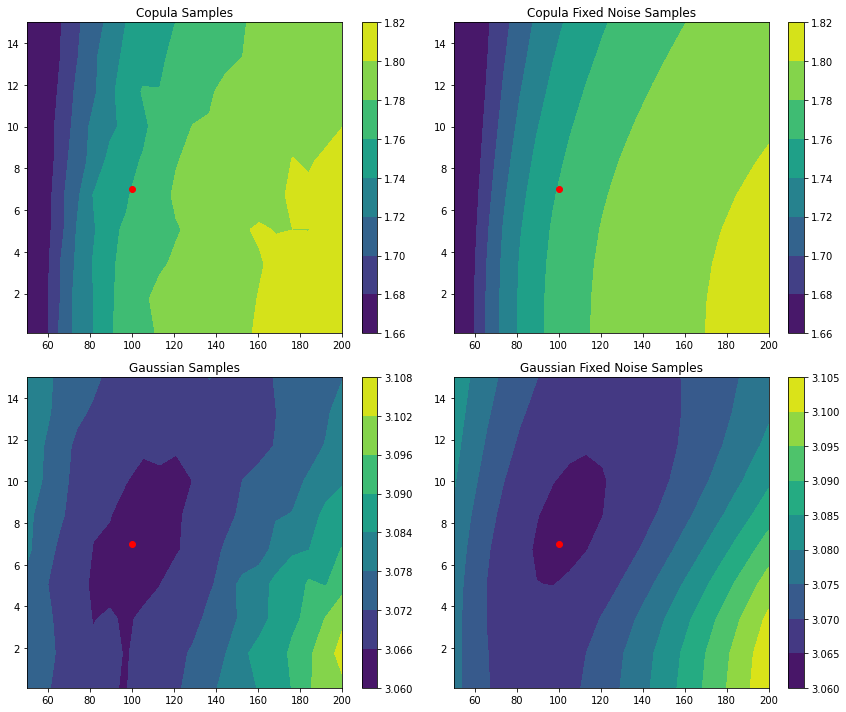

In [ ]:
# Extracting data for plotting
theta_vals = np.linspace(50,200,20)
a_vals = np.linspace(0.1,15,10)
theta_vals, a_vals = np.meshgrid(theta_vals, a_vals)
e_scores_gauss_samples = np.array([score[0] for score in e_scores_per_rho]).reshape(20, 10)
e_scores_gauss_fixed_samples = np.array([score[1] for score in e_scores_per_rho]).reshape(20, 10)
e_scores_cop_samples = np.array([score[0] for score in e_scores_per_rho_cop]).reshape(20, 10)
e_scores_cop_fixed_samples = np.array([score[1] for score in e_scores_per_rho_cop]).reshape(20, 10)

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

contour1 = axs[0, 0].contourf(theta_vals, a_vals, e_scores_cop_samples.T, cmap='viridis')
axs[0, 0].set_title('Copula Samples')
axs[0, 0].scatter(100, 7, color='red', label='True rho')
fig.colorbar(contour1, ax=axs[0, 0])

contour2 = axs[0, 1].contourf(theta_vals, a_vals, e_scores_cop_fixed_samples.T, cmap='viridis')
axs[0, 1].set_title('Copula Fixed Noise Samples')
axs[0, 1].scatter(100, 7, color='red', label='True rho')
fig.colorbar(contour2, ax=axs[0, 1])

contour3 = axs[1, 0].contourf(theta_vals, a_vals, e_scores_gauss_samples.T, cmap='viridis')
axs[1, 0].set_title('Gaussian Samples')
axs[1, 0].scatter(100, 7, color='red', label='True rho')
fig.colorbar(contour3, ax=axs[1, 0])

contour4 = axs[1, 1].contourf(theta_vals, a_vals, e_scores_gauss_fixed_samples.T, cmap='viridis')
axs[1, 1].set_title('Gaussian Fixed Noise Samples')
axs[1, 1].scatter(100, 7, color='red', label='True rho')

fig.colorbar(contour4, ax=axs[1, 1])

plt.tight_layout()
plt.show()

## 4D censored Gaussian copula inference of $\theta, a$ jointly

In [40]:
# On the Gaussian Scale

def sample_Gauss_fixed_noise(noise, chol_cov):
    latent_z = noise @ chol_cov.T
    return latent_z
fixed_noise = scs.norm.rvs(size=(1000, 7*7))

e_scores_per_rho = []
beta = 0.5
for theta_ in tqdm(np.linspace(50,200,20)):
    for a_ in np.linspace(3,15,20):
        estimated_distances = np.hstack((locations, a_ * topos.reshape(-1, 1)))
        estimated_dist_matrix = euclidean_distances(estimated_distances, estimated_distances)
        estimated_cov = Matern(length_scale=theta_, nu=3.5).__call__(estimated_dist_matrix)
        chol_cov = np.linalg.cholesky(estimated_cov)
        gauss_fixed_samples = np.maximum(sample_Gauss_fixed_noise(fixed_noise, chol_cov),scs.norm.ppf(censor_lvl))
        gauss_samples = np.maximum(scs.multivariate_normal.rvs(mean=np.zeros(estimated_cov.shape[0]), cov=estimated_cov, size=1000),scs.norm.ppf(censor_lvl))
        e_scores_per_rho.append([Energy_Score(beta, torch.tensor(latent_z_censored), torch.tensor(gauss_samples)),Energy_Score(beta, torch.tensor(latent_z_censored), torch.tensor(gauss_fixed_samples)),theta_,a_])

# On the Copula Scale


e_scores_per_rho_cop = []
beta = 0.5
for theta_ in tqdm(np.linspace(50,200,20)):
    for a_ in np.linspace(3,15,20):
        estimated_distances = np.hstack((locations, a_ * topos.reshape(-1, 1)))
        estimated_dist_matrix = euclidean_distances(estimated_distances, estimated_distances)
        estimated_cov = Matern(length_scale=theta_, nu=3.5).__call__(estimated_dist_matrix)        
        chol_cov = np.linalg.cholesky(estimated_cov)
        cop_fixed_samples = np.maximum(scs.norm.cdf(sample_Gauss_fixed_noise(fixed_noise, chol_cov)),censor_lvl)
        cop_samples = np.maximum(scs.norm.cdf(scs.multivariate_normal.rvs(mean=np.zeros(estimated_cov.shape[0]), cov=estimated_cov, size=1000)),censor_lvl)
        e_scores_per_rho_cop.append([Energy_Score(beta, torch.tensor(copula_u_censored), torch.tensor(cop_samples)),Energy_Score(beta, torch.tensor(copula_u_censored), torch.tensor(cop_fixed_samples)),theta_,a_])


100%|██████████| 20/20 [02:08<00:00,  6.40s/it]


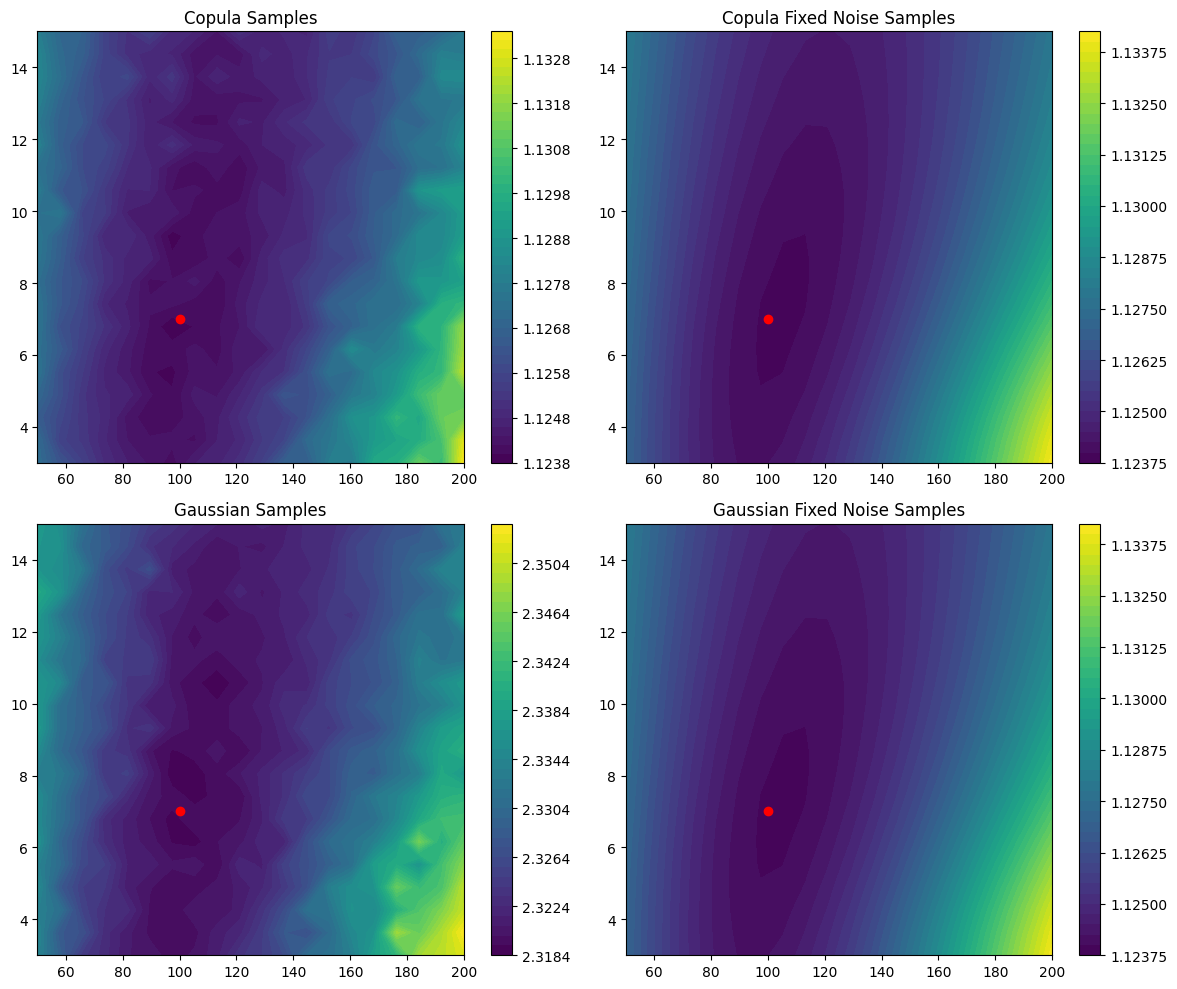

In [46]:
# Extracting data for plotting
theta_vals = np.linspace(50,200,20)
a_vals = np.linspace(3,15,20)
theta_vals, a_vals = np.meshgrid(theta_vals, a_vals)
e_scores_gauss_samples = np.array([score[0] for score in e_scores_per_rho]).reshape(20, 20)
e_scores_gauss_fixed_samples = np.array([score[1] for score in e_scores_per_rho]).reshape(20, 20)
e_scores_cop_samples = np.array([score[0] for score in e_scores_per_rho_cop]).reshape(20, 20)
e_scores_cop_fixed_samples = np.array([score[1] for score in e_scores_per_rho_cop]).reshape(20, 20)

# Plotting
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

contour1 = axs[0, 0].contourf(theta_vals, a_vals, np.sqrt(e_scores_cop_samples).T, cmap='viridis',levels=50)
axs[0, 0].scatter(100, 7, color='red', label='True rho')
axs[0, 0].set_title('Copula Samples')
fig.colorbar(contour1, ax=axs[0, 0])

contour2 = axs[0, 1].contourf(theta_vals, a_vals, np.sqrt(e_scores_cop_fixed_samples).T, cmap='viridis',levels=50)
axs[0, 1].set_title('Copula Fixed Noise Samples')
axs[0, 1].scatter(100, 7, color='red', label='True rho')
fig.colorbar(contour2, ax=axs[0, 1])

contour3 = axs[1, 0].contourf(theta_vals, a_vals, e_scores_gauss_samples.T, cmap='viridis',levels=50)
axs[1, 0].set_title('Gaussian Samples')
axs[1, 0].scatter(100, 7, color='red', label='True rho')
fig.colorbar(contour3, ax=axs[1, 0])

contour4 = axs[1, 1].contourf(theta_vals, a_vals, np.sqrt(e_scores_cop_fixed_samples).T, cmap='viridis',levels=50)
axs[1, 1].set_title('Gaussian Fixed Noise Samples')
axs[1, 1].scatter(100, 7, color='red', label='True rho')
fig.colorbar(contour4, ax=axs[1, 1])

plt.tight_layout()
plt.show()

# Inference with Torch Gradients

In [230]:
from torch import tensor as tt

norm = torch.distributions.Normal(0, 1)

def sample_Gauss_fixed_noise(noise, chol_cov):
    latent_z = noise @ chol_cov.T
    return latent_z

In [10]:
def Energy_Score(energy_beta, observations_y, simulations_Y):
    m = len(simulations_Y)
    diff_Y_y = torch.pow(
        torch.norm(
            (observations_y.unsqueeze(1) -
             simulations_Y.unsqueeze(0)).float(),
            dim=2, keepdim=True).reshape(-1, 1),
        energy_beta)
    diff_Y_Y = 2 * torch.pow(
        nn.functional.pdist(simulations_Y),
        energy_beta)
    Energy = 2 * torch.mean(diff_Y_y) - torch.sum(diff_Y_Y) / (m * (m - 1))
    return Energy

In [232]:
def torch_Matern_05(dist_matrix, rho):
    K = torch.exp(-dist_matrix / rho)
    return K

def torch_Matern_15(dist_matrix, rho):
    block = (tt(3.).sqrt()*dist_matrix) / rho
    K = (1+ block) * torch.exp( -block ) 
    return K

def torch_Matern_25(dist_matrix, rho):
    block = (tt(5.).sqrt()*dist_matrix) / rho
    K = (1+ block + (block**2) /3) * torch.exp( -block ) 
    return K

print(Matern(length_scale=10, nu=0.5).__call__(locations),torch_Matern_05(dist_matrix,tt(10)))
print(Matern(length_scale=10, nu=1.5).__call__(locations),torch_Matern_15(dist_matrix,tt(10)))
print(Matern(length_scale=10, nu=2.5).__call__(locations),torch_Matern_25(dist_matrix,tt(10)))


[[1.         0.24311673 0.05910575 0.0143696 ]
 [0.24311673 1.         0.24311673 0.05910575]
 [0.05910575 0.24311673 1.         0.24311673]
 [0.0143696  0.05910575 0.24311673 1.        ]] tensor([[1.0000, 0.2430, 0.0590, 0.0143],
        [0.2430, 1.0000, 0.2428, 0.0590],
        [0.0590, 0.2428, 1.0000, 0.2431],
        [0.0143, 0.0590, 0.2431, 1.0000]], dtype=torch.float64)
[[1.         0.29782077 0.04397209 0.00537288]
 [0.29782077 1.         0.29782077 0.04397209]
 [0.04397209 0.29782077 1.         0.29782077]
 [0.00537288 0.04397209 0.29782077 1.        ]] tensor([[1.0000, 0.2977, 0.0439, 0.0054],
        [0.2977, 1.0000, 0.2973, 0.0439],
        [0.0439, 0.2973, 1.0000, 0.2978],
        [0.0054, 0.0439, 0.2978, 1.0000]], dtype=torch.float64)
[[1.         0.31728336 0.03701404 0.00307068]
 [0.31728336 1.         0.31728336 0.03701404]
 [0.03701404 0.31728336 1.         0.31728336]
 [0.00307068 0.03701404 0.31728336 1.        ]] tensor([[1.0000, 0.3171, 0.0369, 0.0031],
        [0.

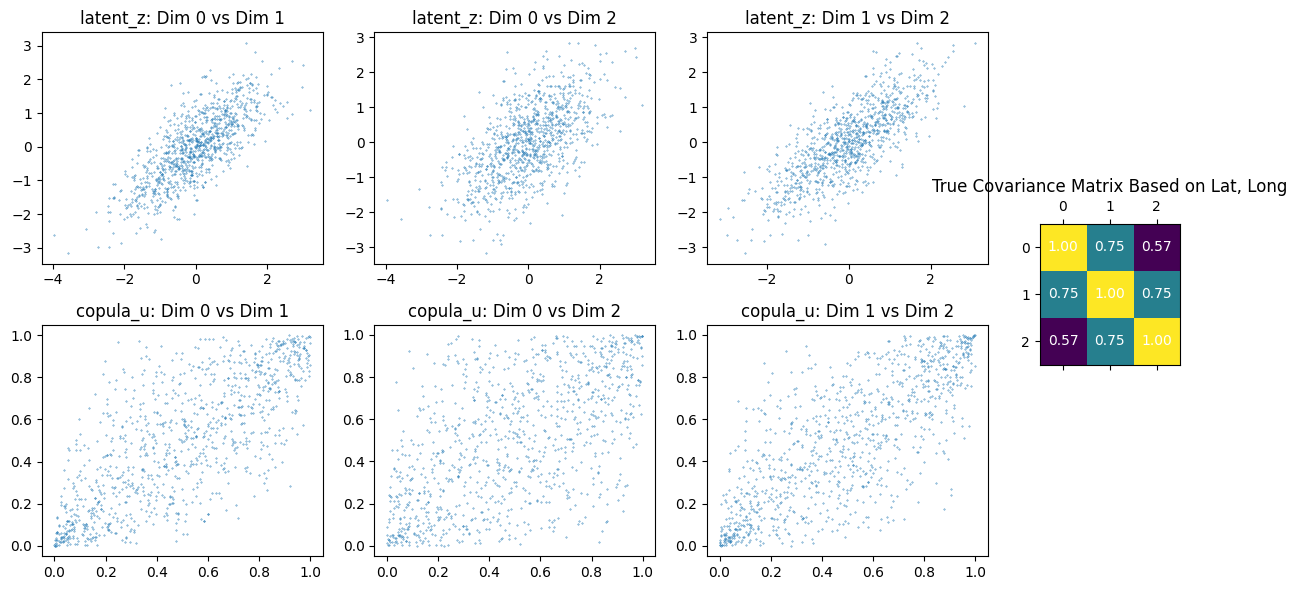

In [233]:
from sklearn.metrics.pairwise import euclidean_distances 

locations = np.array([[0, 0], [10, 10], [20, 20]])
dist_matrix = tt(euclidean_distances(locations, locations))
true_cov = torch_Matern_05(dist_matrix, tt(50))

latent_z = sample_Gauss_fixed_noise(norm.sample((1000, 3)).to(dtype=torch.float64), torch.cholesky(true_cov))
copula_u = norm.cdf(latent_z)

# Create subplots
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 0.5])

# Scatter pair plots for latent_z
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(latent_z[:, 0], latent_z[:, 1], s=0.1)
ax1.set_title('latent_z: Dim 0 vs Dim 1')

ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(latent_z[:, 0], latent_z[:, 2], s=0.1)
ax2.set_title('latent_z: Dim 0 vs Dim 2')

ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(latent_z[:, 1], latent_z[:, 2], s=0.1)
ax3.set_title('latent_z: Dim 1 vs Dim 2')

# Scatter pair plots for copula_u
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(copula_u[:, 0], copula_u[:, 1], s=0.1)
ax4.set_title('copula_u: Dim 0 vs Dim 1')

ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(copula_u[:, 0], copula_u[:, 2], s=0.1)
ax5.set_title('copula_u: Dim 0 vs Dim 2')

ax6 = fig.add_subplot(gs[1, 2])
ax6.scatter(copula_u[:, 1], copula_u[:, 2], s=0.1)
ax6.set_title('copula_u: Dim 1 vs Dim 2')

# Plot the covariance matrix
ax7 = fig.add_subplot(gs[:, 3])
cax = ax7.matshow(true_cov, cmap='viridis')
ax7.set_title('True Covariance Matrix Based on Lat, Long')

# Annotate the matrix with the covariance values
for (i, j), val in np.ndenumerate(true_cov):
    ax7.text(j, i, f'{val:.2f}', ha='center', va='center', color='white')

plt.tight_layout()
plt.show()

In [35]:
SR_z = []
SR_u = []


fixed_noise = norm.sample((1000,latent_z.shape[1])).to(dtype=torch.float64)

for theta in tqdm(torch.linspace(30, 70, 20)):
    est_cov = torch_Matern_05(dist_matrix, theta)
    chol_cov = torch.linalg.cholesky(est_cov)
    sims_z = sample_Gauss_fixed_noise(fixed_noise, chol_cov)
    sims_u = norm.cdf(sims_z)
    SR_z.append(Energy_Score(0.5, latent_z, sims_z))
    SR_u.append(Energy_Score(0.5, copula_u, sims_u))

100%|██████████| 20/20 [00:00<00:00, 24.95it/s]


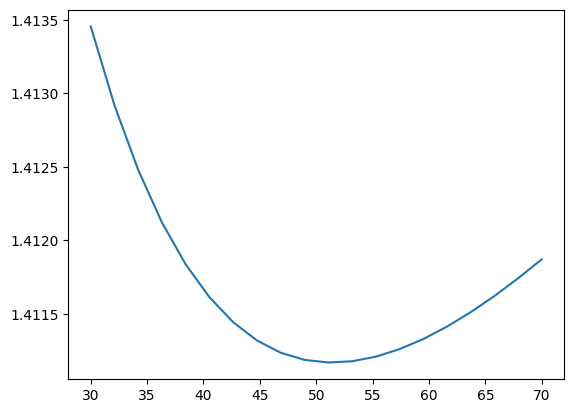

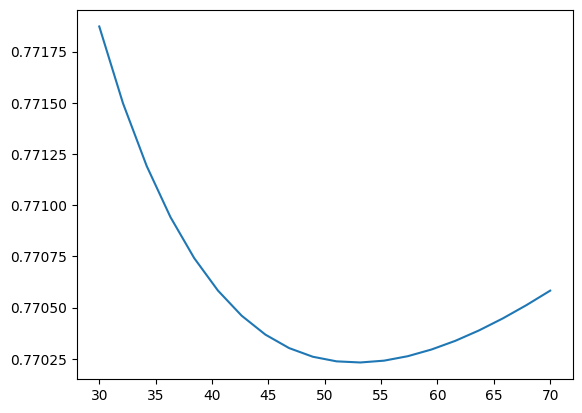

In [36]:
plt.plot(torch.linspace(30, 70, 20), SR_z, label='SR on latent_z')
plt.show()
plt.plot(torch.linspace(30, 70, 20), SR_u, label='SR on copula_u')
plt.show()

### optimsation

In [ ]:
SR_z = []

fixed_noise = norm.sample((1000,latent_z.shape[1])).to(dtype=torch.float64)
theta = tt(20.,requires_grad=True)

optimizer = torch.optim.Adam([theta], lr=1)
# latent_z
for epoch in tqdm(range(100)):
    optimizer.zero_grad()
    est_cov = torch_Matern_05(dist_matrix, theta)
    chol_cov = torch.linalg.cholesky(est_cov)
    sims_z = sample_Gauss_fixed_noise(fixed_noise, chol_cov)
    loss = Energy_Score(0.5, latent_z, sims_z)
    loss.backward()
    if epoch % 50 == 0:
        print(f'Epoch {epoch}: Loss = {loss.item()}, Theta Gradient = {theta.grad.item()}, Theta = {theta.item()}')

    optimizer.step()
    with torch.no_grad():
        SR_z.append([theta.item(),loss.item()])
    

  4%|▍         | 4/100 [00:00<00:05, 17.62it/s]

Epoch 0: Loss = 1.4177198147189436, Theta Gradient = -0.000734558270778507, Theta = 20.0


 54%|█████▍    | 54/100 [00:03<00:02, 17.96it/s]

Epoch 50: Loss = 1.4103866256484767, Theta Gradient = -2.219758607679978e-05, Theta = 49.240779876708984


100%|██████████| 100/100 [00:05<00:00, 17.28it/s]


C:\Users\u1819911\AppData\Local\Temp\ipykernel_9360\721632798.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  SR_z = tt(SR_z)


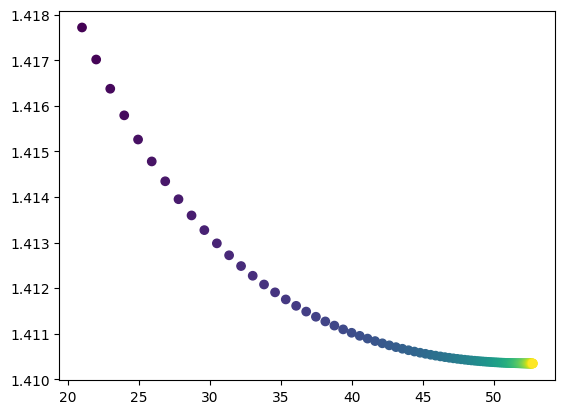

In [93]:
SR_z = tt(SR_z)
plt.scatter(SR_z[:,0],SR_z[:,1],c=range(100))

In [ ]:
SR_u = []

fixed_noise = norm.sample((1000,latent_z.shape[1])).to(dtype=torch.float64)
theta = tt(20.,requires_grad=True)

optimizer = torch.optim.Adam([theta], lr=1)
# copula_u
for epoch in tqdm(range(100)):
    optimizer.zero_grad()
    est_cov = torch_Matern_05(dist_matrix, theta)
    chol_cov = torch.linalg.cholesky(est_cov)
    sims_z = sample_Gauss_fixed_noise(fixed_noise, chol_cov)
    sims_u = norm.cdf(sims_z)
    loss = Energy_Score(0.5, copula_u, sims_u)
    loss.backward()
    if epoch % 50 == 0:
        print(f'Epoch {epoch}: Loss = {loss.item()}, Theta Gradient = {theta.grad.item()}, Theta = {theta.item()}')

    optimizer.step()
    with torch.no_grad():
        SR_u.append([theta.item(),loss.item()])

  4%|▍         | 4/100 [00:00<00:05, 16.67it/s]

Epoch 0: Loss = 0.7754634416236268, Theta Gradient = -0.0005210306844674051, Theta = 20.0


 54%|█████▍    | 54/100 [00:03<00:02, 17.74it/s]

Epoch 50: Loss = 0.7703495287671922, Theta Gradient = -1.4866926903778221e-05, Theta = 49.04520797729492


100%|██████████| 100/100 [00:05<00:00, 17.22it/s]


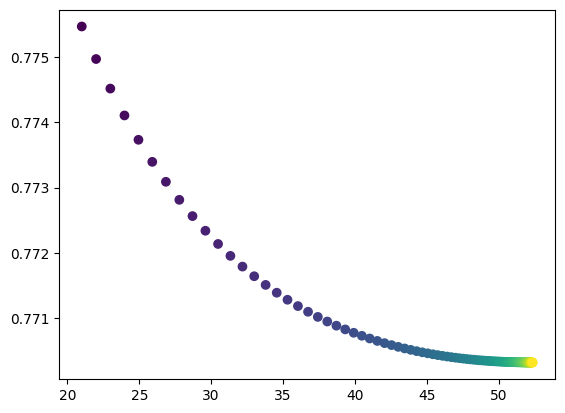

In [95]:
SR_u = tt(SR_u)
plt.scatter(SR_u[:,0],SR_u[:,1],c=range(100))

## censoring and torch

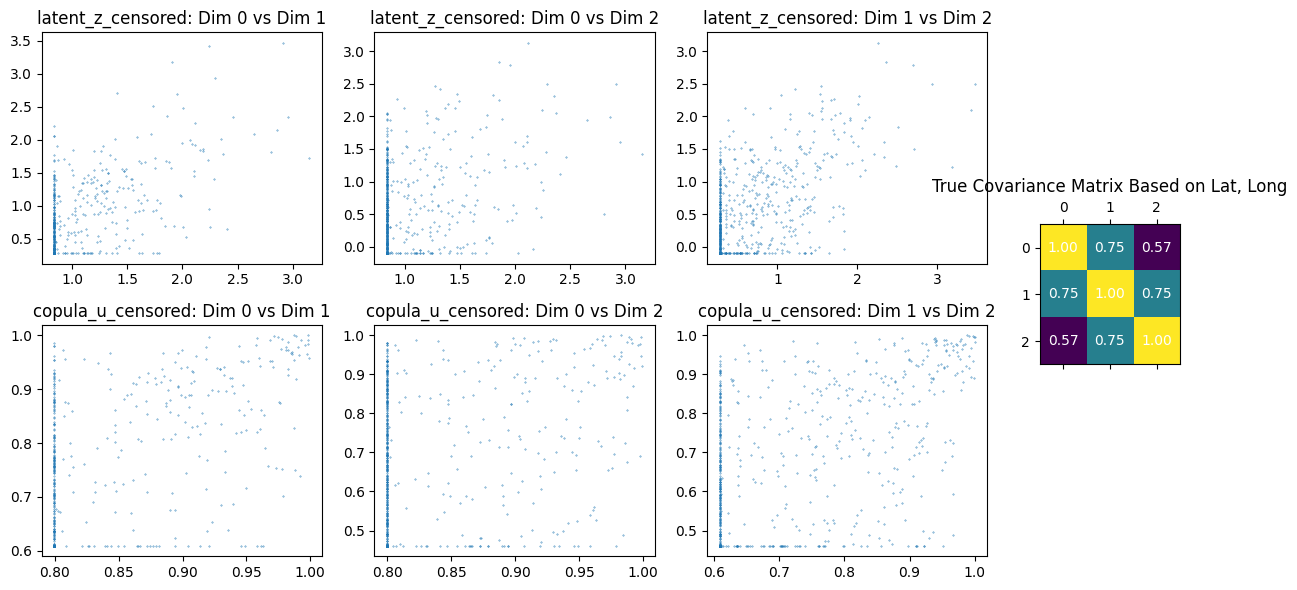

In [97]:
censor_levels = torch.rand(latent_z.shape[1])
latent_z_censored = torch.maximum(latent_z, norm.icdf(censor_levels))
copula_u_censored = torch.maximum(copula_u, censor_levels)

# Create subplots
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(2, 4, width_ratios=[1, 1, 1, 0.5])

# Scatter pair plots for latent_z
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(latent_z_censored[:, 0], latent_z_censored[:, 1], s=0.1)
ax1.set_title('latent_z_censored: Dim 0 vs Dim 1')

ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(latent_z_censored[:, 0], latent_z_censored[:, 2], s=0.1)
ax2.set_title('latent_z_censored: Dim 0 vs Dim 2')

ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(latent_z_censored[:, 1], latent_z_censored[:, 2], s=0.1)
ax3.set_title('latent_z_censored: Dim 1 vs Dim 2')

# Scatter pair plots for copula_u
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(copula_u_censored[:, 0], copula_u_censored[:, 1], s=0.1)
ax4.set_title('copula_u_censored: Dim 0 vs Dim 1')

ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(copula_u_censored[:, 0], copula_u_censored[:, 2], s=0.1)
ax5.set_title('copula_u_censored: Dim 0 vs Dim 2')

ax6 = fig.add_subplot(gs[1, 2])
ax6.scatter(copula_u_censored[:, 1], copula_u_censored[:, 2], s=0.1)
ax6.set_title('copula_u_censored: Dim 1 vs Dim 2')

# Plot the covariance matrix
ax7 = fig.add_subplot(gs[:, 3])
cax = ax7.matshow(true_cov, cmap='viridis')
ax7.set_title('True Covariance Matrix Based on Lat, Long')

# Annotate the matrix with the covariance values
for (i, j), val in np.ndenumerate(true_cov):
    ax7.text(j, i, f'{val:.2f}', ha='center', va='center', color='white')

plt.tight_layout()
plt.show()

In [98]:
SR_z = []
censor_lvl_z = norm.icdf(censor_levels)
fixed_noise = norm.sample((1000,latent_z.shape[1])).to(dtype=torch.float64)
theta = tt(20.,requires_grad=True)

optimizer = torch.optim.Adam([theta], lr=1)
# latent_z CENSORED
for epoch in tqdm(range(100)):
    optimizer.zero_grad()
    est_cov = torch_Matern_05(dist_matrix, theta)
    chol_cov = torch.linalg.cholesky(est_cov)
    sims_z = sample_Gauss_fixed_noise(fixed_noise, chol_cov)
    sims_z = torch.maximum(sims_z, censor_lvl_z)
    loss = Energy_Score(0.5, latent_z_censored, sims_z)
    loss.backward()
    if epoch % 50 == 0:
        print(f'Epoch {epoch}: Loss = {loss.item()}, Theta Gradient = {theta.grad.item()}, Theta = {theta.item()}')

    optimizer.step()
    with torch.no_grad():
        SR_z.append([theta.item(),loss.item()])
    

  4%|▍         | 4/100 [00:00<00:05, 16.21it/s]

Epoch 0: Loss = 0.8127244785539384, Theta Gradient = -0.0005513732903636992, Theta = 20.0


 54%|█████▍    | 54/100 [00:03<00:02, 16.96it/s]

Epoch 50: Loss = 0.808881690866136, Theta Gradient = 2.585622723927372e-06, Theta = 42.663272857666016


100%|██████████| 100/100 [00:05<00:00, 17.09it/s]


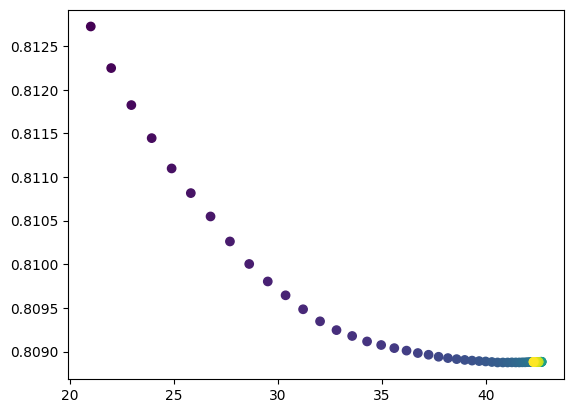

In [99]:
SR_z = tt(SR_z)
plt.scatter(SR_z[:,0],SR_z[:,1],c=range(100))

In [100]:
SR_u = []

fixed_noise = norm.sample((1000,latent_z.shape[1])).to(dtype=torch.float64)
theta = tt(20.,requires_grad=True)

optimizer = torch.optim.Adam([theta], lr=1)
# copula_u
for epoch in tqdm(range(100)):
    optimizer.zero_grad()
    est_cov = torch_Matern_05(dist_matrix, theta)
    chol_cov = torch.linalg.cholesky(est_cov)
    sims_z = sample_Gauss_fixed_noise(fixed_noise, chol_cov)
    sims_u = norm.cdf(sims_z)
    sims_u = torch.maximum(sims_u, censor_levels)
    loss = Energy_Score(0.5, copula_u_censored, sims_u)
    loss.backward()
    if epoch % 50 == 0:
        print(f'Epoch {epoch}: Loss = {loss.item()}, Theta Gradient = {theta.grad.item()}, Theta = {theta.item()}')

    optimizer.step()
    with torch.no_grad():
        SR_u.append([theta.item(),loss.item()])

  4%|▍         | 4/100 [00:00<00:06, 15.90it/s]

Epoch 0: Loss = 0.4368168241080508, Theta Gradient = -0.0003442467132117599, Theta = 20.0


 54%|█████▍    | 54/100 [00:03<00:02, 16.95it/s]

Epoch 50: Loss = 0.43357892562002415, Theta Gradient = 2.6429670469951816e-06, Theta = 46.90171432495117


100%|██████████| 100/100 [00:06<00:00, 16.18it/s]


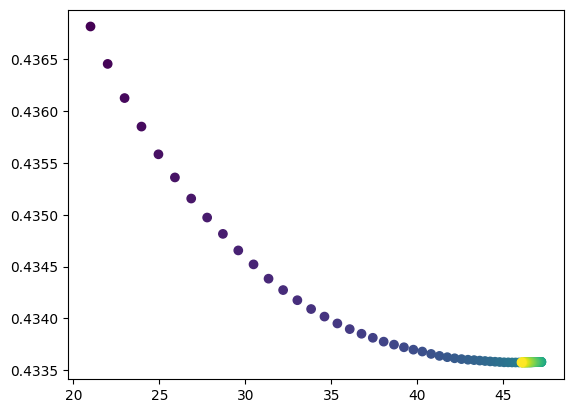

In [101]:
SR_u = tt(SR_u)
plt.scatter(SR_u[:,0],SR_u[:,1],c=range(100))

### higher!

In [6]:
import numpy as np
import torch
from sklearn.metrics.pairwise import euclidean_distances

# Define the functions
def torch_Matern_05(dist_matrix, rho):
    K = torch.exp(-dist_matrix / rho)
    return K

def sample_Gauss_fixed_noise(fixed_noise, chol_cov):
    return fixed_noise @ chol_cov.T

# Define the normal distribution
mean = 0.0
std_dev = 1.0
norm = torch.distributions.Normal(mean, std_dev)

# Define the number of locations
n_loc = 10  # Example value, you can change this

# Sample locations increasing by 10
locations = np.array([[i * 10, i * 10] for i in range(n_loc)])

# Compute the distance matrix
dist_matrix = torch.tensor(euclidean_distances(locations, locations), dtype=torch.float64)

# Compute the true covariance matrix using the Matern kernel
true_cov = torch_Matern_05(dist_matrix, torch.tensor(50.0, dtype=torch.float64))

# Sample latent variables
fixed_noise = norm.sample((1000, n_loc)).to(dtype=torch.float64)
latent_z = sample_Gauss_fixed_noise(fixed_noise, torch.cholesky(true_cov))

# Compute the copula
copula_u = norm.cdf(latent_z)

# Print the results
print("Locations:\n", locations)
print("Distance Matrix:\n", dist_matrix)
print("True Covariance Matrix:\n", true_cov)
print("Latent Variables:\n", latent_z)
print("Copula:\n", copula_u)

Locations:
 [[ 0  0]
 [10 10]
 [20 20]
 [30 30]
 [40 40]
 [50 50]
 [60 60]
 [70 70]
 [80 80]
 [90 90]]
Distance Matrix:
 tensor([[  0.0000,  14.1421,  28.2843,  42.4264,  56.5685,  70.7107,  84.8528,
          98.9949, 113.1371, 127.2792],
        [ 14.1421,   0.0000,  14.1421,  28.2843,  42.4264,  56.5685,  70.7107,
          84.8528,  98.9949, 113.1371],
        [ 28.2843,  14.1421,   0.0000,  14.1421,  28.2843,  42.4264,  56.5685,
          70.7107,  84.8528,  98.9949],
        [ 42.4264,  28.2843,  14.1421,   0.0000,  14.1421,  28.2843,  42.4264,
          56.5685,  70.7107,  84.8528],
        [ 56.5685,  42.4264,  28.2843,  14.1421,   0.0000,  14.1421,  28.2843,
          42.4264,  56.5685,  70.7107],
        [ 70.7107,  56.5685,  42.4264,  28.2843,  14.1421,   0.0000,  14.1421,
          28.2843,  42.4264,  56.5685],
        [ 84.8528,  70.7107,  56.5685,  42.4264,  28.2843,  14.1421,   0.0000,
          14.1421,  28.2843,  42.4264],
        [ 98.9949,  84.8528,  70.7107,  56.568

C:\Users\u1819911\AppData\Local\Temp\ipykernel_22856\2056150711.py:32: UserWarning: torch.cholesky is deprecated in favor of torch.linalg.cholesky and will be removed in a future PyTorch release.
L = torch.cholesky(A)
should be replaced with
L = torch.linalg.cholesky(A)
and
U = torch.cholesky(A, upper=True)
should be replaced with
U = torch.linalg.cholesky(A).mH
This transform will produce equivalent results for all valid (symmetric positive definite) inputs. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\BatchLinearAlgebra.cpp:1702.)
  latent_z = sample_Gauss_fixed_noise(fixed_noise, torch.cholesky(true_cov))


In [109]:
n_loc = 50

locations = np.array([[i * 10, i * 10] for i in range(n_loc)])
dist_matrix = tt(euclidean_distances(locations, locations), dtype=torch.float64)
true_cov = torch_Matern_05(dist_matrix, tt(50., dtype=torch.float64))

latent_z = sample_Gauss_fixed_noise(norm.sample((1000, true_cov.shape[0])).to(dtype=torch.float64), torch.cholesky(true_cov))
copula_u = norm.cdf(latent_z)

censor_levels = torch.rand(latent_z.shape[1])
latent_z_censored = torch.maximum(latent_z, norm.icdf(censor_levels))
copula_u_censored = torch.maximum(copula_u, censor_levels)

In [112]:
SR_z = []
censor_lvl_z = norm.icdf(censor_levels)
fixed_noise = norm.sample((1000,latent_z.shape[1])).to(dtype=torch.float64)
theta = tt(20.,requires_grad=True)

optimizer = torch.optim.Adam([theta], lr=1)
# latent_z CENSORED
for epoch in tqdm(range(100)):
    optimizer.zero_grad()
    est_cov = torch_Matern_05(dist_matrix, theta)
    chol_cov = torch.linalg.cholesky(est_cov)
    sims_z = sample_Gauss_fixed_noise(fixed_noise, chol_cov)
    sims_z = torch.maximum(sims_z, censor_lvl_z)
    loss = Energy_Score(0.5, latent_z_censored, sims_z)
    loss.backward()
    if epoch % 50 == 0:
        print(f'Epoch {epoch}: Loss = {loss.item()}, Theta Gradient = {theta.grad.item()}, Theta = {theta.item()}')

    optimizer.step()
    with torch.no_grad():
        SR_z.append([theta.item(),loss.item()])
    

  1%|          | 1/100 [00:00<00:54,  1.82it/s]

Epoch 0: Loss = 2.514386824821759, Theta Gradient = -0.00027358808438293636, Theta = 20.0


 51%|█████     | 51/100 [00:29<00:26,  1.85it/s]

Epoch 50: Loss = 2.510547663608757, Theta Gradient = -1.2115319805161562e-06, Theta = 52.30099868774414


100%|██████████| 100/100 [00:56<00:00,  1.77it/s]


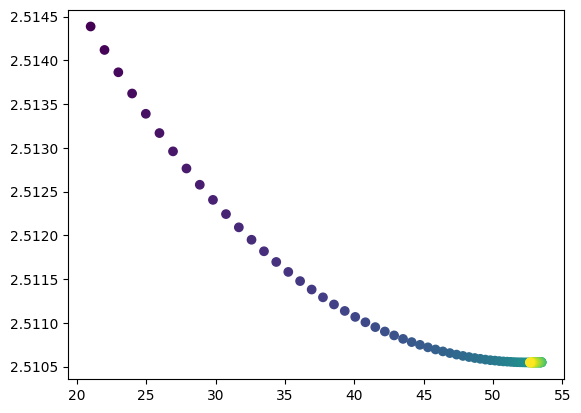

In [113]:
SR_z = tt(SR_z)
plt.scatter(SR_z[:,0],SR_z[:,1],c=range(100))

In [110]:
SR_u = []

fixed_noise = norm.sample((1000,latent_z.shape[1])).to(dtype=torch.float64)
theta = tt(20.,requires_grad=True)

optimizer = torch.optim.Adam([theta], lr=1)
# copula_u
for epoch in tqdm(range(100)):
    optimizer.zero_grad()
    est_cov = torch_Matern_05(dist_matrix, theta)
    chol_cov = torch.linalg.cholesky(est_cov)
    sims_z = sample_Gauss_fixed_noise(fixed_noise, chol_cov)
    sims_u = norm.cdf(sims_z)
    sims_u = torch.maximum(sims_u, censor_levels)
    loss = Energy_Score(0.5, copula_u_censored, sims_u)
    loss.backward()
    if epoch % 50 == 0:
        print(f'Epoch {epoch}: Loss = {loss.item()}, Theta Gradient = {theta.grad.item()}, Theta = {theta.item()}')

    optimizer.step()
    with torch.no_grad():
        SR_u.append([theta.item(),loss.item()])

  1%|          | 1/100 [00:00<00:49,  2.00it/s]

Epoch 0: Loss = 1.3658181858688718, Theta Gradient = -0.00011888017616001889, Theta = 20.0


 51%|█████     | 51/100 [00:30<00:28,  1.74it/s]

Epoch 50: Loss = 1.364385076171212, Theta Gradient = 3.702918320414028e-06, Theta = 49.221099853515625


100%|██████████| 100/100 [01:01<00:00,  1.62it/s]


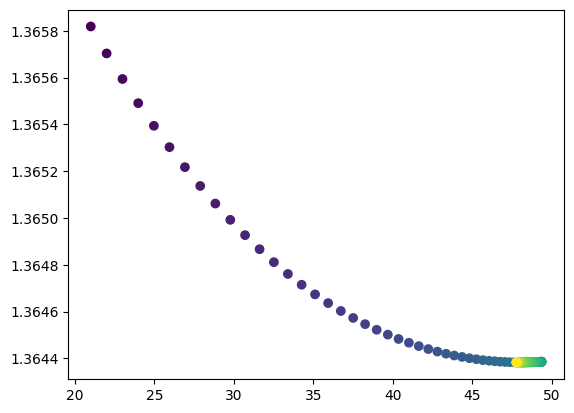

In [111]:
SR_u = tt(SR_u)
plt.scatter(SR_u[:,0],SR_u[:,1],c=range(100))

## Censoring with a,theta using torch

In [4]:
from torch import tensor as tt

In [7]:
n_loc = 3

locations = tt([[i * 10, i * 10] for i in range(n_loc)], dtype=torch.float64)
topo = torch.sin(locations.mean(dim=1)/30)**2 *4
dist_3d = torch.column_stack([locations, tt(30.) * topo])
dist_matrix = torch.cdist(dist_3d, dist_3d)
true_cov = torch_Matern_05(dist_matrix, tt(50., dtype=torch.float64))

latent_z = sample_Gauss_fixed_noise(norm.sample((1000, true_cov.shape[0])).to(dtype=torch.float64), torch.cholesky(true_cov))
copula_u = norm.cdf(latent_z)

censor_levels = torch.rand(latent_z.shape[1])
latent_z_censored = torch.maximum(latent_z, norm.icdf(censor_levels))
copula_u_censored = torch.maximum(copula_u, censor_levels)

true_cov

tensor([[1.0000, 0.6824, 0.3403],
        [0.6824, 1.0000, 0.4874],
        [0.3403, 0.4874, 1.0000]], dtype=torch.float64)

In [16]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm



# Define the range of theta and a_ values
theta_values = torch.linspace(30, 70, 20)
a_values = torch.linspace(10, 50, 20)

# Initialize the result array
energy_scores = np.zeros((len(theta_values), len(a_values)))

# Compute the energy scores for each combination of theta and a_
fixed_noise = norm.sample((2000, latent_z.shape[1])).to(dtype=torch.float64)
for i, theta in enumerate(tqdm(theta_values)):
    for j, a_ in enumerate(a_values):
        estimated_dist_3d = torch.column_stack([locations, a_ * topo])
        est_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)
        est_cov = torch_Matern_05(est_dist_matrix, theta)
        chol_cov = torch.linalg.cholesky(est_cov)
        sims_z = sample_Gauss_fixed_noise(fixed_noise, chol_cov)
        sims_u = norm.cdf(sims_z)
        sims_u = torch.maximum(sims_u, censor_levels)
        loss = Energy_Score(0.5, copula_u_censored, sims_u)
        energy_scores[i, j] = loss.item()


100%|██████████| 20/20 [00:19<00:00,  1.02it/s]


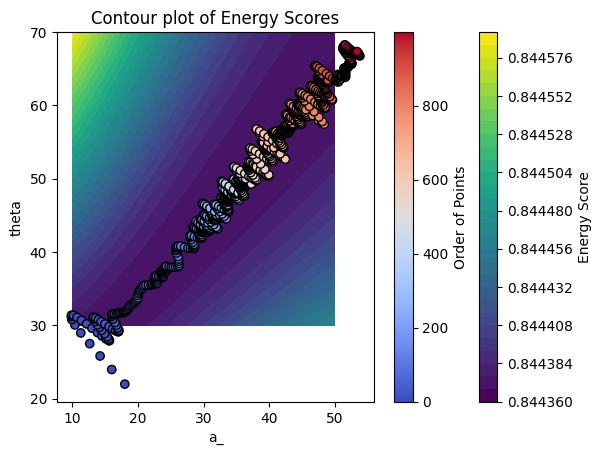

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from tqdm import tqdm



# Create the contour plot
X, Y = np.meshgrid(a_values.numpy(), theta_values.numpy())
plt.contourf(X, Y, np.power(energy_scores, 1/5), cmap='viridis', levels=30)
plt.colorbar(label='Energy Score')
plt.xlabel('a_')
plt.ylabel('theta')
plt.title('Contour plot of Energy Scores')
SR_u = np.array(SR_u)

scatter = plt.scatter(SR_u[:, 1], SR_u[:, 0], c=np.arange(len(SR_u)), cmap='coolwarm', edgecolor='k')

plt.colorbar(scatter, label='Order of Points')

# Plot the points from SR_u

plt.show()

In [ ]:
SR_u = []

# Define the normal distribution
mean = 0.0
std_dev = 1.0
norm = torch.distributions.Normal(mean, std_dev)

fixed_noise = norm.sample((2000,latent_z.shape[1])).to(dtype=torch.float64)
theta = tt(20.,requires_grad=True)
a_ = tt(20.,requires_grad=True)

optimizer = torch.optim.Adam([theta,a_], lr=2)
# copula_u
for epoch in tqdm(range(1000)):
    optimizer.zero_grad()
    estimated_dist_3d = torch.column_stack([locations, a_ * topo])
    est_dist_matrix = torch.cdist(estimated_dist_3d, estimated_dist_3d)
    est_cov = torch_Matern_05(est_dist_matrix, theta)
    chol_cov = torch.linalg.cholesky(est_cov)
    sims_z = sample_Gauss_fixed_noise(fixed_noise, chol_cov)
    sims_u = norm.cdf(sims_z)
    sims_u = torch.maximum(sims_u, censor_levels)
    loss = Energy_Score(0.5, copula_u_censored, sims_u)
    loss.backward()
    if epoch % 10 == 0:
        print(f'Epoch {epoch}: Loss = {loss.item()}, Theta Gradient = {theta.grad.item()}, Theta = {theta.item()}, a Gradient = {a_.grad.item()}, a = {a_.item()}')

    optimizer.step()
    with torch.no_grad():
        SR_u.append([theta.item(),a_.item(),loss.item()])

  0%|          | 2/1000 [00:00<02:48,  5.92it/s]

Epoch 0: Loss = 0.4293470130082945, Theta Gradient = -1.8519998775445856e-05, Theta = 20.0, a Gradient = 8.883218470145948e-06, a = 20.0


  1%|          | 12/1000 [00:02<03:02,  5.41it/s]

Epoch 10: Loss = 0.4292237122224976, Theta Gradient = 7.455138074874412e-06, Theta = 31.380037307739258, a Gradient = -5.448746833280893e-06, a = 10.154570579528809


  2%|▏         | 22/1000 [00:04<02:56,  5.54it/s]

...

 98%|█████████▊| 982/1000 [02:38<00:02,  6.30it/s]

Epoch 980: Loss = 0.4291987548518123, Theta Gradient = -6.423786089726491e-07, Theta = 67.14913177490234, a Gradient = 6.83622317865229e-07, a = 52.616336822509766


 99%|█████████▉| 992/1000 [02:39<00:01,  6.48it/s]

Epoch 990: Loss = 0.4291985953852802, Theta Gradient = -3.7617300563397293e-07, Theta = 67.43051147460938, a Gradient = 3.730829973846994e-07, a = 52.65457534790039


100%|██████████| 1000/1000 [02:41<00:00,  6.20it/s]


In [13]:
theta,a_

(tensor(67.3409, requires_grad=True), tensor(53.4042, requires_grad=True))